# lead scoring



In [1]:
#importing all the necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline

In [2]:
#importing data set


In [3]:
lead_df=pd.read_csv("leads.csv")

In [4]:
lead_df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [5]:
#checking the shape of imported dataset
lead_df.shape


(9240, 37)

In [6]:
lead_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [7]:
lead_df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [8]:
#we will now find the number of unique values in each column if len(column)= unique value we can delete that column

In [9]:
lead_df.nunique()

Prospect ID                                      9240
Lead Number                                      9240
Lead Origin                                         5
Lead Source                                        21
Do Not Email                                        2
Do Not Call                                         2
Converted                                           2
TotalVisits                                        41
Total Time Spent on Website                      1731
Page Views Per Visit                              114
Last Activity                                      17
Country                                            38
Specialization                                     19
How did you hear about X Education                 10
What is your current occupation                     6
What matters most to you in choosing a course       3
Search                                              2
Magazine                                            1
Newspaper Article           

In [10]:
# dropping columns having only one unique value because they do not provide variation for model building
unique_values = lead_df.columns[lead_df.nunique() == 1]
unique_values

Index(['Magazine', 'Receive More Updates About Our Courses',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'I agree to pay the amount through cheque'],
      dtype='object')

In [11]:
lead_df.drop(labels= unique_values,axis='columns',inplace=True) 

In [12]:
# dropping lead number  and prospect id because of all unique values


In [13]:
lead_df.drop(['Prospect ID','Lead Number'], axis=1,inplace=True)

In [14]:
lead_df.head()

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Tags,Lead Quality,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,Interested in other courses,Low in Relevance,Select,Select,02.Medium,02.Medium,15.0,15.0,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,Ringing,NaN,Select,Select,02.Medium,02.Medium,15.0,15.0,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,Will revert after reading the email,Might be,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,Ringing,Not Sure,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,Will revert after reading the email,Might be,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,Modified


In [15]:
# it is given that select in some categorical could mean that it is a null value so lets convert it.
lead_df.replace('Select',np.nan,inplace=True)

In [16]:
#lets check if it worked
lead_df['Lead Profile'].value_counts()

Lead Profile
Potential Lead                 1613
Other Leads                     487
Student of SomeSchool           241
Lateral Student                  24
Dual Specialization Student      20
Name: count, dtype: int64

In [17]:
#checking for missing values percentage

In [18]:
round(lead_df.isnull().sum()/len(lead_df)*100, 2).sort_values(ascending=False)

How did you hear about X Education               78.46
Lead Profile                                     74.19
Lead Quality                                     51.59
Asymmetrique Profile Score                       45.65
Asymmetrique Activity Score                      45.65
Asymmetrique Profile Index                       45.65
Asymmetrique Activity Index                      45.65
City                                             39.71
Specialization                                   36.58
Tags                                             36.29
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
Page Views Per Visit                              1.48
TotalVisits                                       1.48
Last Activity                                     1.11
Lead Source                                       0.39
A free copy of Mastering The Interview            0.00
Lead Origi

In [19]:
# Lead Profile has a high percentage of missing values and Lead Quality also has a significant amount of missing values.
# Columns with more than 30% missing observations are considered for removal because imputing such a large proportion
# of the values may introduce strong assumptions.
# This threshold is used as a practical data-cleaning rule for this analysis.
null_value1 = lead_df.isnull().sum() * 100 / len(lead_df)
null_value1 = null_value1[null_value1.values > 30.00]
null_value1.sort_values(ascending=False)


How did you hear about X Education    78.463203
Lead Profile                          74.188312
Lead Quality                          51.590909
Asymmetrique Activity Index           45.649351
Asymmetrique Profile Index            45.649351
Asymmetrique Activity Score           45.649351
Asymmetrique Profile Score            45.649351
City                                  39.707792
Specialization                        36.580087
Tags                                  36.287879
dtype: float64

In [20]:
#dropping all the columns having huge null values
lead_df.drop(labels=null_value1.index,axis='columns',inplace=True)

In [21]:
lead_df.head()

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,What matters most to you in choosing a course,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Student,Better Career Prospects,No,No,No,No,No,No,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Modified


In [22]:
lead_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 20 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Origin                                    9240 non-null   object 
 1   Lead Source                                    9204 non-null   object 
 2   Do Not Email                                   9240 non-null   object 
 3   Do Not Call                                    9240 non-null   object 
 4   Converted                                      9240 non-null   int64  
 5   TotalVisits                                    9103 non-null   float64
 6   Total Time Spent on Website                    9240 non-null   int64  
 7   Page Views Per Visit                           9103 non-null   float64
 8   Last Activity                                  9137 non-null   object 
 9   Country                                        6779 

In [23]:
lead_df.shape

(9240, 20)

In [24]:
lead_df.nunique()

Lead Origin                                         5
Lead Source                                        21
Do Not Email                                        2
Do Not Call                                         2
Converted                                           2
TotalVisits                                        41
Total Time Spent on Website                      1731
Page Views Per Visit                              114
Last Activity                                      17
Country                                            38
What is your current occupation                     6
What matters most to you in choosing a course       3
Search                                              2
Newspaper Article                                   2
X Education Forums                                  2
Newspaper                                           2
Digital Advertisement                               2
Through Recommendations                             2
A free copy of Mastering The

In [25]:
unique_columns = lead_df.columns[lead_df.nunique()>0]
unique_columns

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call',
       'Converted', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Last Activity', 'Country',
       'What is your current occupation',
       'What matters most to you in choosing a course', 'Search',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [26]:
#writin a loop to find all the uniques values of each column of the data set
for i in unique_columns:
    x = lead_df[i].value_counts(normalize=True)
    print(f'The unique values in {i} is', '\n')
    print(x,'\n')
    print('-'*100,'\n')

The unique values in Lead Origin is 

Lead Origin
Landing Page Submission    0.528788
API                        0.387446
Lead Add Form              0.077706
Lead Import                0.005952
Quick Add Form             0.000108
Name: proportion, dtype: float64 

---------------------------------------------------------------------------------------------------- 

The unique values in Lead Source is 

Lead Source
Google               0.311604
Direct Traffic       0.276293
Olark Chat           0.190678
Organic Search       0.125380
Reference            0.058018
Welingak Website     0.015428
Referral Sites       0.013581
Facebook             0.005976
bing                 0.000652
google               0.000543
Click2call           0.000435
Press_Release        0.000217
Social Media         0.000217
Live Chat            0.000217
youtubechannel       0.000109
testone              0.000109
Pay per Click Ads    0.000109
welearnblog_Home     0.000109
WeLearn              0.000109
blog        

In [27]:
# Starting from the above we will make changes in the lead source because Google and google are the same
lead_df['Lead Source'].replace('google','Google',inplace=True)

In [28]:
round(100*(lead_df.isnull().sum()/len(lead_df)), 2).sort_values(ascending=False)

What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
TotalVisits                                       1.48
Page Views Per Visit                              1.48
Last Activity                                     1.11
Lead Source                                       0.39
Newspaper Article                                 0.00
A free copy of Mastering The Interview            0.00
Through Recommendations                           0.00
Digital Advertisement                             0.00
Newspaper                                         0.00
X Education Forums                                0.00
Lead Origin                                       0.00
Search                                            0.00
Total Time Spent on Website                       0.00
Converted                                         0.00
Do Not Call                                       0.00
Do Not Ema

In [29]:
#(lead source,TotalVisits,Page Views Per Visit, 'Last Activity) has some missing values we will replace them with mode 
lead_df['Lead Source'].fillna(lead_df['Lead Source'].mode()[0],inplace=True)

lead_df['TotalVisits'].fillna(lead_df['TotalVisits'].mode()[0],inplace=True)

lead_df['Page Views Per Visit'].fillna(lead_df['Page Views Per Visit'].mode()[0],inplace=True)

lead_df['Last Activity'].fillna(lead_df['Last Activity'].mode()[0],inplace=True)

In [30]:
round(100*(lead_df.isnull().sum()/len(lead_df)), 2).sort_values(ascending=False)

What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
A free copy of Mastering The Interview            0.00
Through Recommendations                           0.00
Digital Advertisement                             0.00
Newspaper                                         0.00
X Education Forums                                0.00
Newspaper Article                                 0.00
Search                                            0.00
Lead Origin                                       0.00
Lead Source                                       0.00
Last Activity                                     0.00
Page Views Per Visit                              0.00
Total Time Spent on Website                       0.00
TotalVisits                                       0.00
Converted                                         0.00
Do Not Call                                       0.00
Do Not Ema

In [31]:
#imputing values of others

lead_df.Country.value_counts()

Country
India                   6492
United States             69
United Arab Emirates      53
Singapore                 24
Saudi Arabia              21
United Kingdom            15
Australia                 13
Qatar                     10
Hong Kong                  7
Bahrain                    7
Oman                       6
France                     6
unknown                    5
South Africa               4
Nigeria                    4
Germany                    4
Kuwait                     4
Canada                     4
Sweden                     3
China                      2
Asia/Pacific Region        2
Uganda                     2
Bangladesh                 2
Italy                      2
Belgium                    2
Netherlands                2
Ghana                      2
Philippines                2
Russia                     1
Switzerland                1
Vietnam                    1
Denmark                    1
Tanzania                   1
Liberia                    1
Malays

In [32]:
#India seems to be the most common value so we are going to impute value 'India' for null values using mode

lead_df['Country'].fillna(lead_df['Country'].mode()[0],inplace=True)

#this is also very repeating values to we might have to drop country in future

In [33]:
lead_df['What is your current occupation'].value_counts()

What is your current occupation
Unemployed              5600
Working Professional     706
Student                  210
Other                     16
Housewife                 10
Businessman                8
Name: count, dtype: int64

In [34]:
#imputing the missing value with the most common used value

lead_df['What is your current occupation'].fillna(lead_df['What is your current occupation'].mode()[0],inplace=True)

In [35]:
lead_df['What matters most to you in choosing a course'].value_counts()

What matters most to you in choosing a course
Better Career Prospects      6528
Flexibility & Convenience       2
Other                           1
Name: count, dtype: int64

In [36]:
#imputing the missing value with the most common used value

lead_df['What matters most to you in choosing a course'].fillna(lead_df['What matters most to you in choosing a course'].mode()[0],inplace=True)

In [37]:
#final check if there are any more missing values

round(100*(lead_df.isnull().sum()/len(lead_df)), 2).sort_values(ascending=False)

Lead Origin                                      0.0
Lead Source                                      0.0
A free copy of Mastering The Interview           0.0
Through Recommendations                          0.0
Digital Advertisement                            0.0
Newspaper                                        0.0
X Education Forums                               0.0
Newspaper Article                                0.0
Search                                           0.0
What matters most to you in choosing a course    0.0
What is your current occupation                  0.0
Country                                          0.0
Last Activity                                    0.0
Page Views Per Visit                             0.0
Total Time Spent on Website                      0.0
TotalVisits                                      0.0
Converted                                        0.0
Do Not Call                                      0.0
Do Not Email                                  

In [38]:
#All null values are dealt with  now we have to proceed

lead_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 20 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Origin                                    9240 non-null   object 
 1   Lead Source                                    9240 non-null   object 
 2   Do Not Email                                   9240 non-null   object 
 3   Do Not Call                                    9240 non-null   object 
 4   Converted                                      9240 non-null   int64  
 5   TotalVisits                                    9240 non-null   float64
 6   Total Time Spent on Website                    9240 non-null   int64  
 7   Page Views Per Visit                           9240 non-null   float64
 8   Last Activity                                  9240 non-null   object 
 9   Country                                        9240 

In [39]:
lead_df.head()

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,What matters most to you in choosing a course,Search,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Modified
1,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,Student,Better Career Prospects,No,No,No,No,No,No,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Unreachable,India,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Modified
4,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,Modified


In [40]:
# checking the distribution of categorical variables before deciding whether any variables need further cleaning

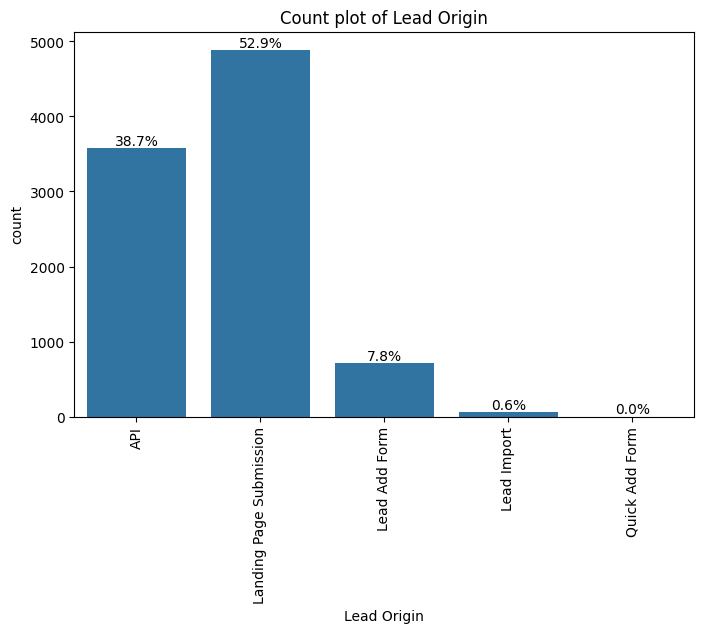

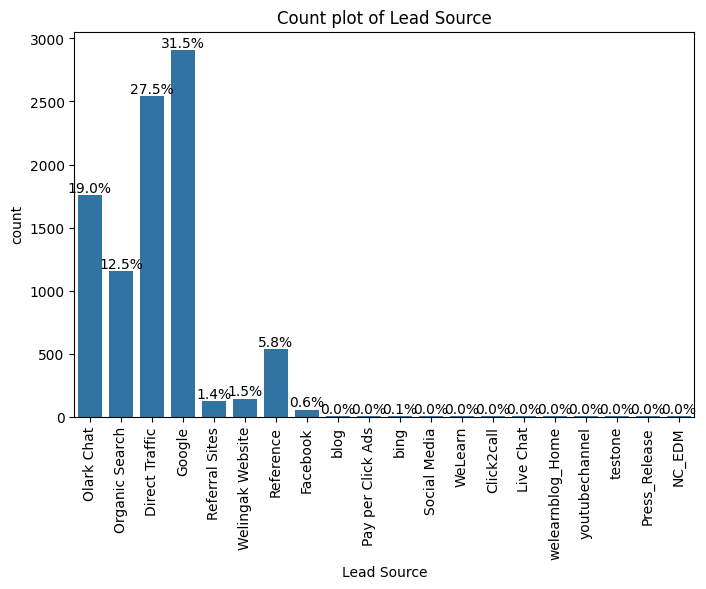

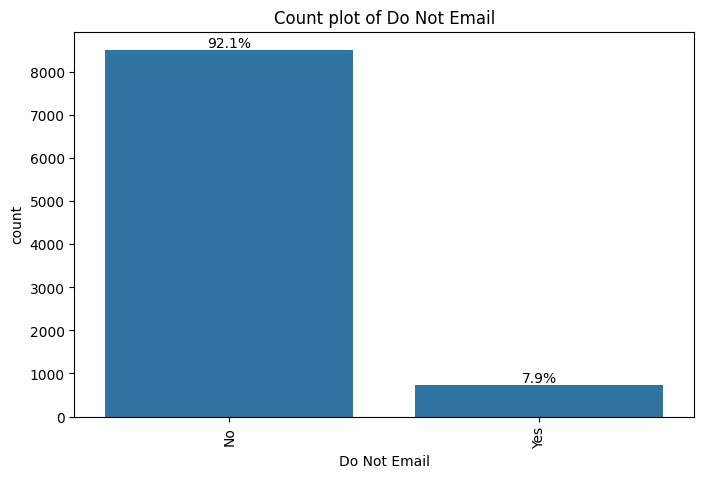

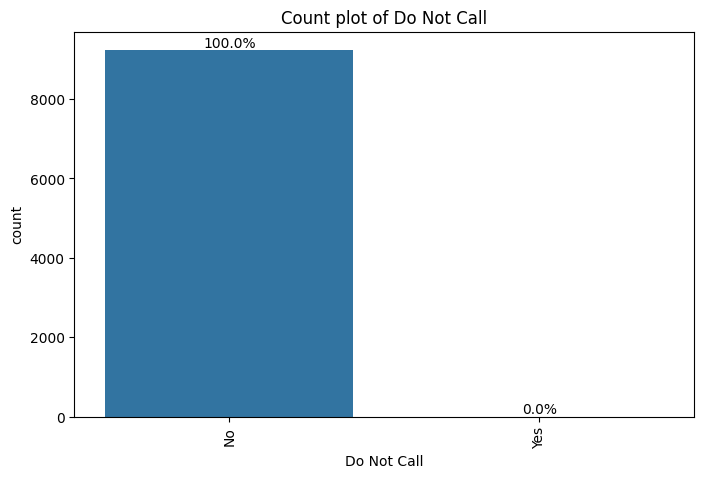

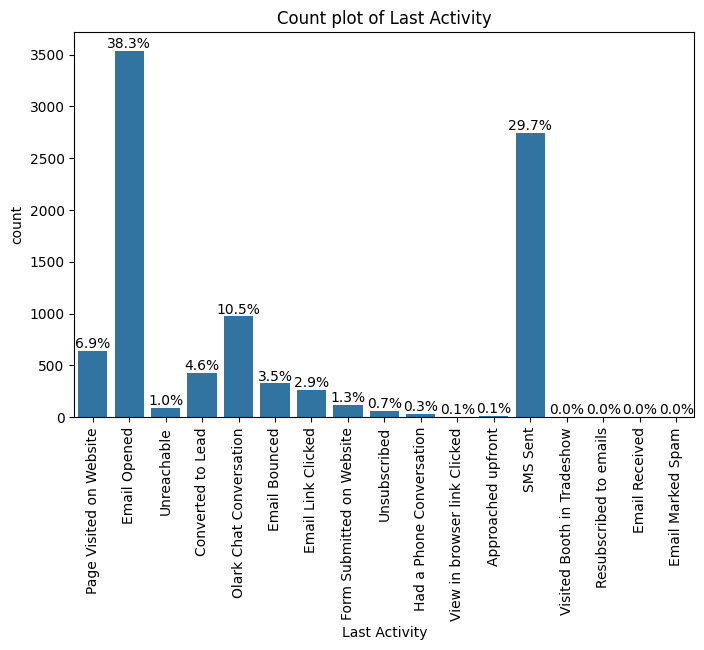

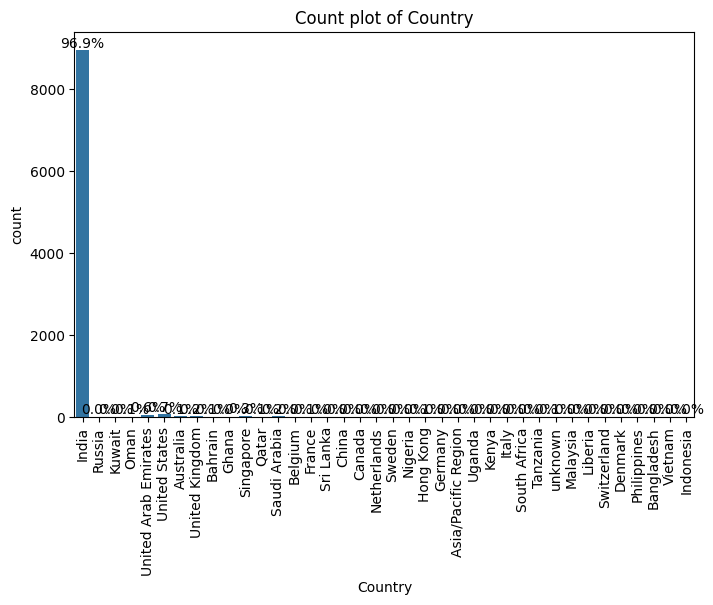

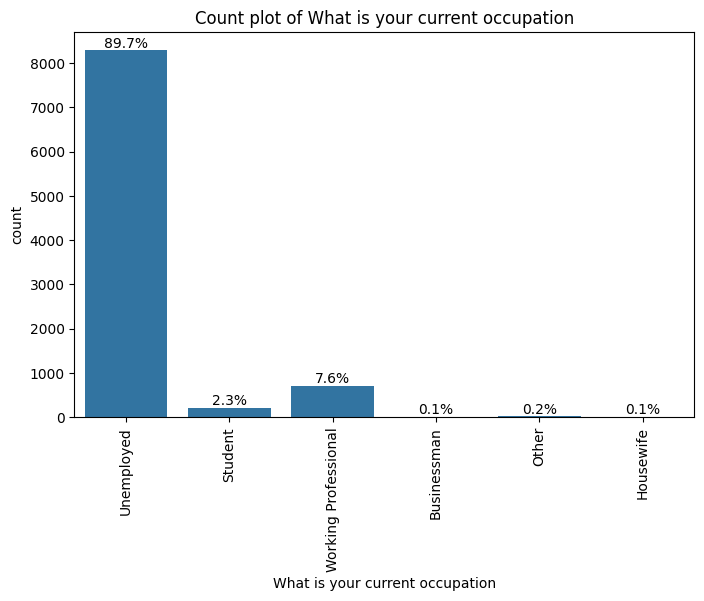

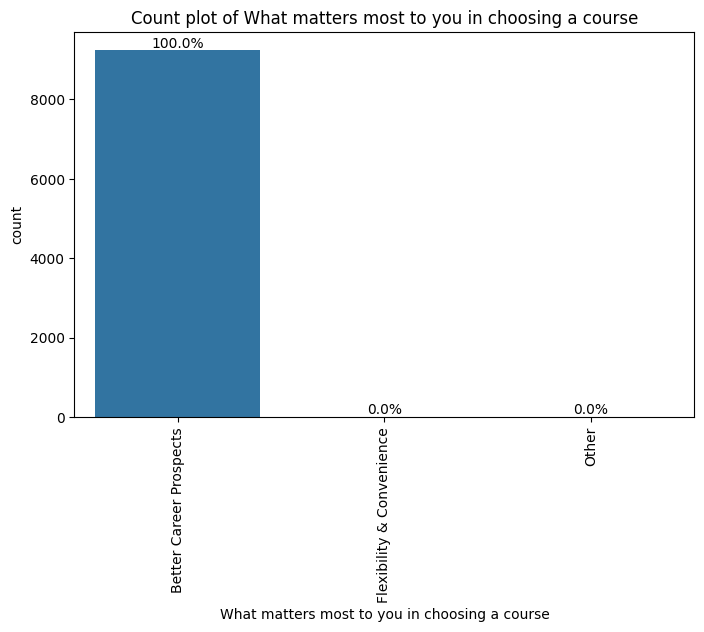

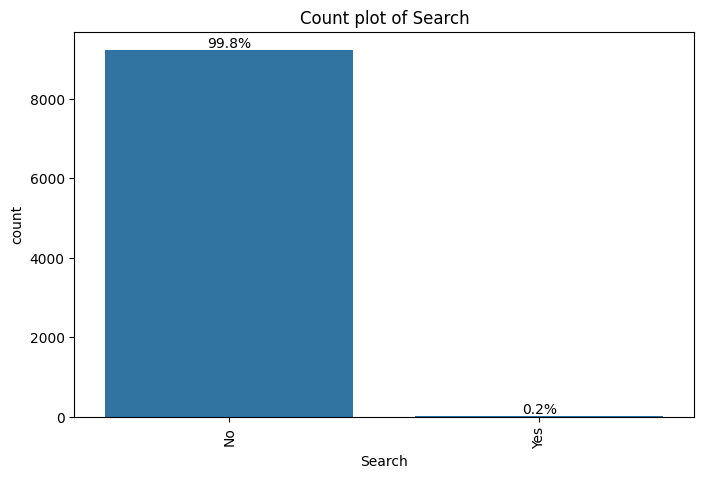

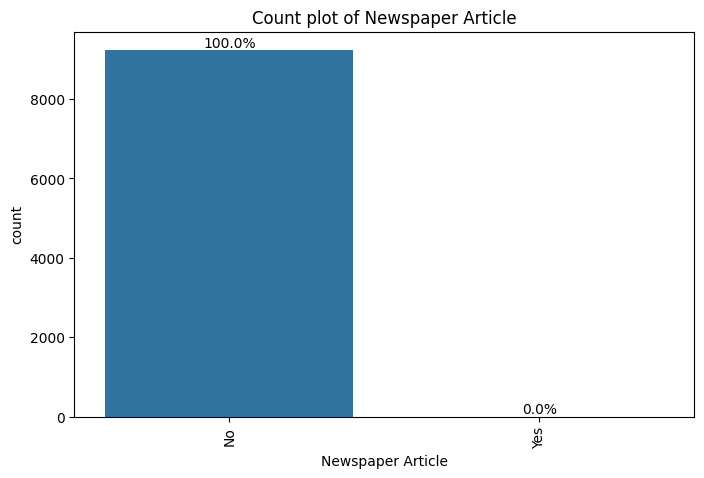

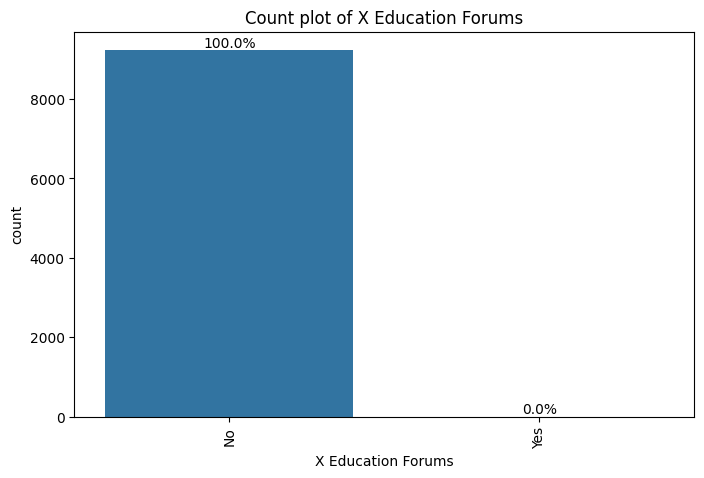

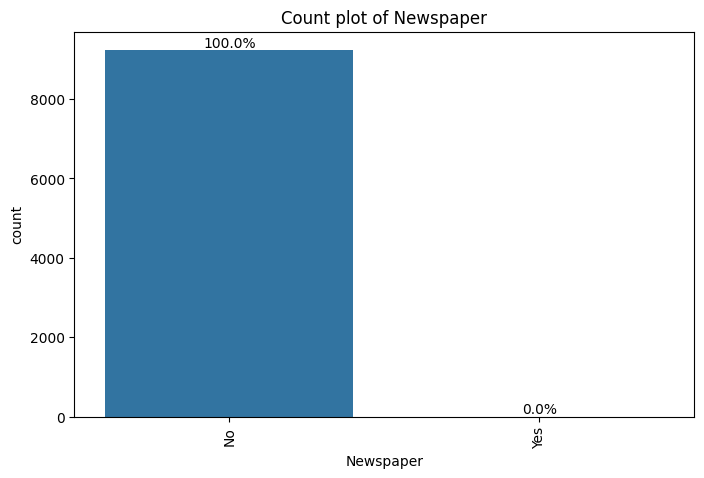

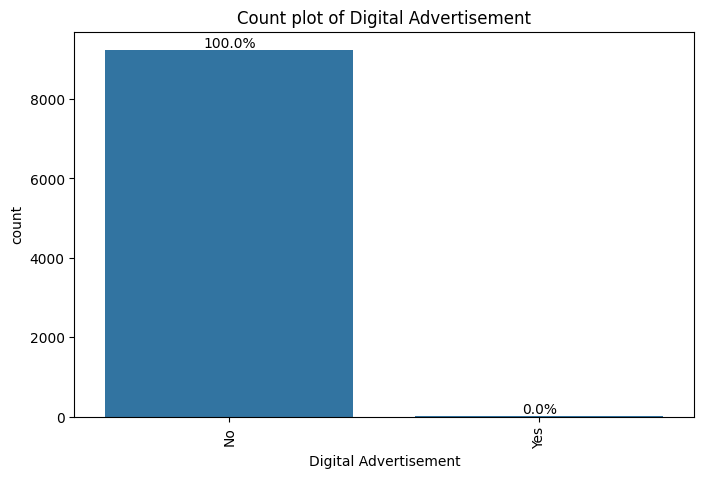

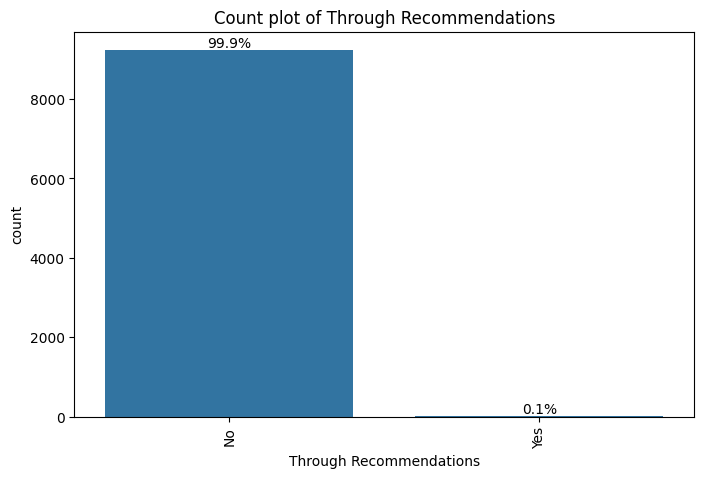

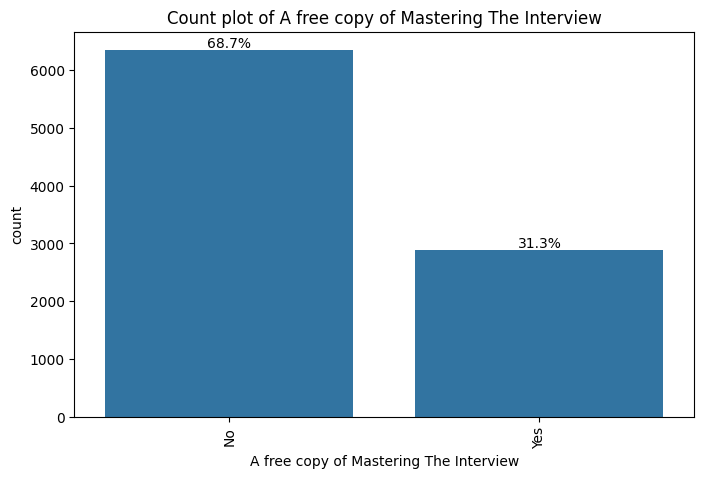

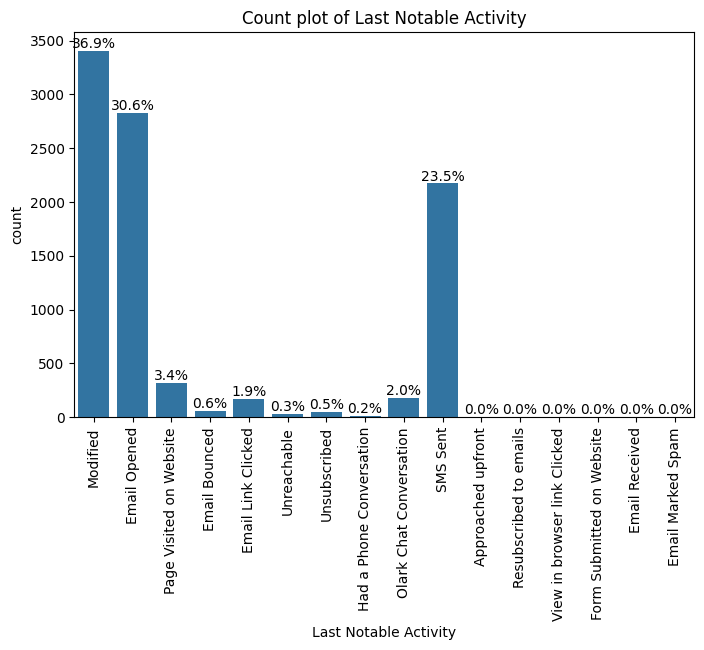

['Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Last Activity', 'Country', 'What is your current occupation', 'What matters most to you in choosing a course', 'Search', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'A free copy of Mastering The Interview', 'Last Notable Activity']


In [41]:
columns_list = lead_df.select_dtypes(include=['category', 'object']).columns.tolist()

for i in columns_list[:]:
    plt.figure(figsize = [8,5])
    plt.title(f"Count plot of {i}")
    plot = sns.countplot(x=i, data=lead_df)
    plt.xticks(rotation=90)
    for p in plot.patches:
        text = '{:.1f}%'.format(100*p.get_height()/len(lead_df[i]))
        x = p.get_x() + p.get_width() / 2.
        y = p.get_height()
        plot.annotate(text, (x,y), ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')
        
plt.show()
print(columns_list)

In [42]:
# Some categorical variables contain very small categories.
# Extremely rare categories can create sparse dummy variables, so the variables below are removed based on their
# limited representation in the dataset and their usefulness for the analysis.
lead_df.drop(['Through Recommendations','Digital Advertisement','Newspaper','X Education Forums','Newspaper Article','Search','What matters most to you in choosing a course','Do Not Call'], axis=1, inplace=True)

In [43]:
lead_df.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,No,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,No,Modified
1,API,Organic Search,No,0,5.0,674,2.5,Email Opened,India,Unemployed,No,Email Opened
2,Landing Page Submission,Direct Traffic,No,1,2.0,1532,2.0,Email Opened,India,Student,Yes,Email Opened
3,Landing Page Submission,Direct Traffic,No,0,1.0,305,1.0,Unreachable,India,Unemployed,No,Modified
4,Landing Page Submission,Google,No,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,No,Modified


In [44]:
lead_df.describe(percentiles=[0.25,0.5,0.75,0.9,0.99])

,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit
count,9240.000000,9240.000000,9240.000000,9240.000000
mean,0.385390,3.394156,487.698268,2.327787
std,0.486714,4.836682,548.021466,2.164258
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,12.000000,0.000000
50%,0.000000,3.000000,248.000000,2.000000
75%,1.000000,5.000000,936.000000,3.000000
90%,1.000000,7.000000,1380.000000,5.000000
99%,1.000000,17.000000,1840.610000,9.000000
max,1.000000,251.000000,2272.000000,55.000000


## EDA

<Axes: ylabel='TotalVisits'>

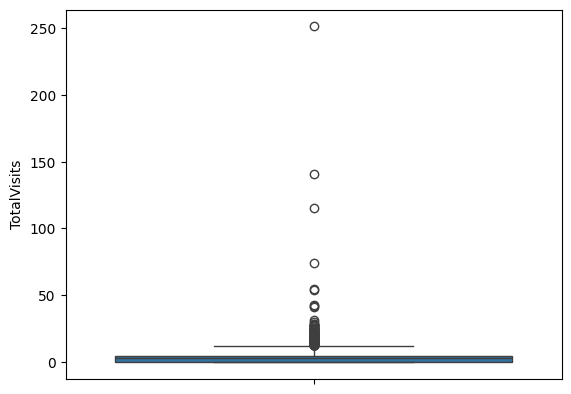

In [45]:
#OUTLIERS
sns.boxplot(lead_df['TotalVisits'])

<Axes: ylabel='Total Time Spent on Website'>

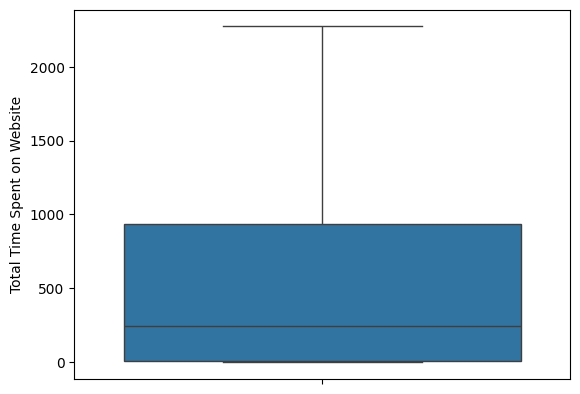

In [46]:
sns.boxplot(lead_df['Total Time Spent on Website'])

<Axes: ylabel='Page Views Per Visit'>

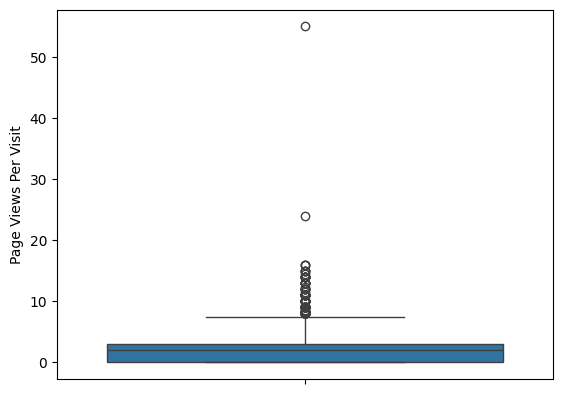

In [47]:
sns.boxplot(lead_df['Page Views Per Visit'])


In [48]:
#OBSERVATIONS

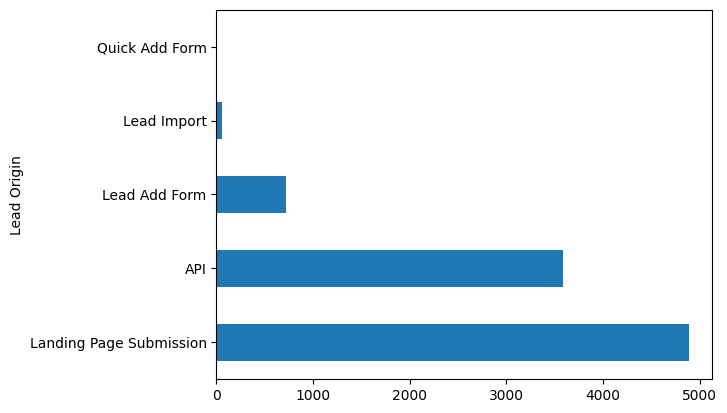

In [49]:
# UNIVARIATE ANALYSIS 
lead_df["Lead Origin"].value_counts().plot.barh()
plt.show()



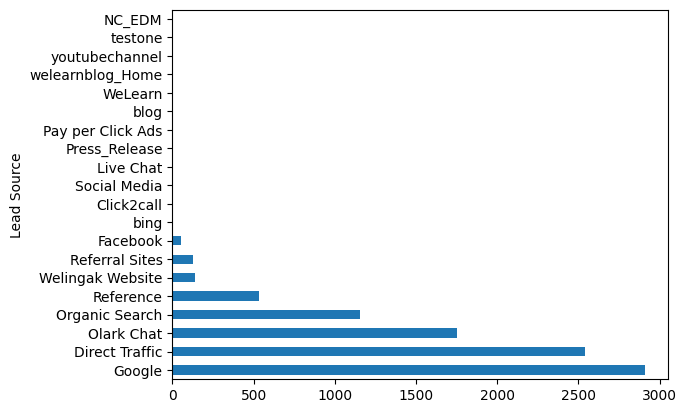

In [50]:
lead_df["Lead Source"].value_counts().plot.barh()
plt.show()

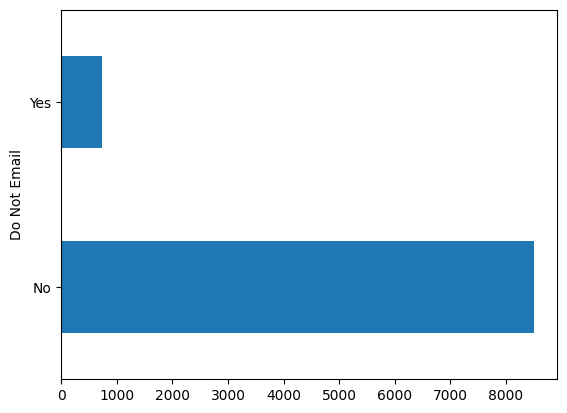

In [51]:
lead_df["Do Not Email"].value_counts().plot.barh()
plt.show()

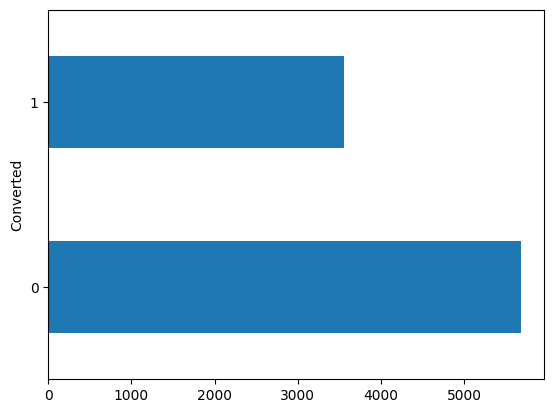

In [52]:
#checking data imbalance


lead_df["Converted"].value_counts().plot.barh()
plt.show()

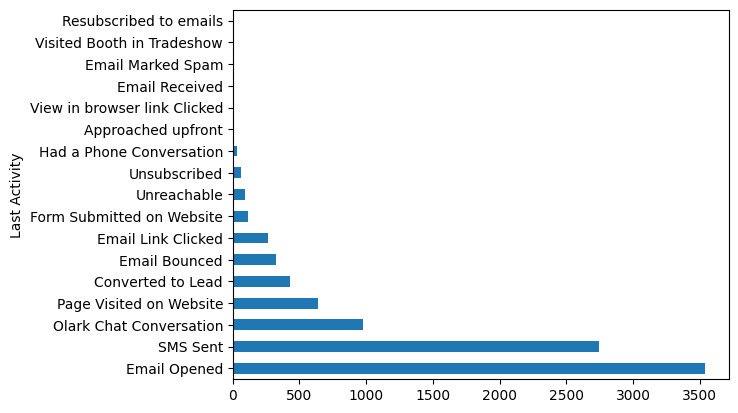

In [53]:

lead_df["Last Activity"].value_counts().plot.barh()
plt.show()

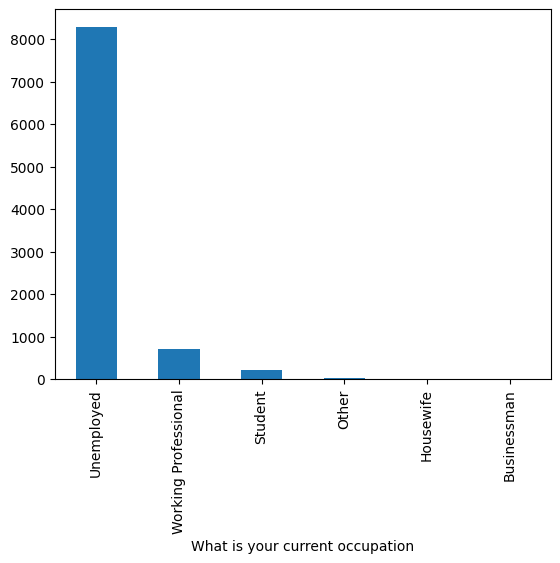

In [54]:

lead_df["What is your current occupation"].value_counts().plot.bar()
plt.show()

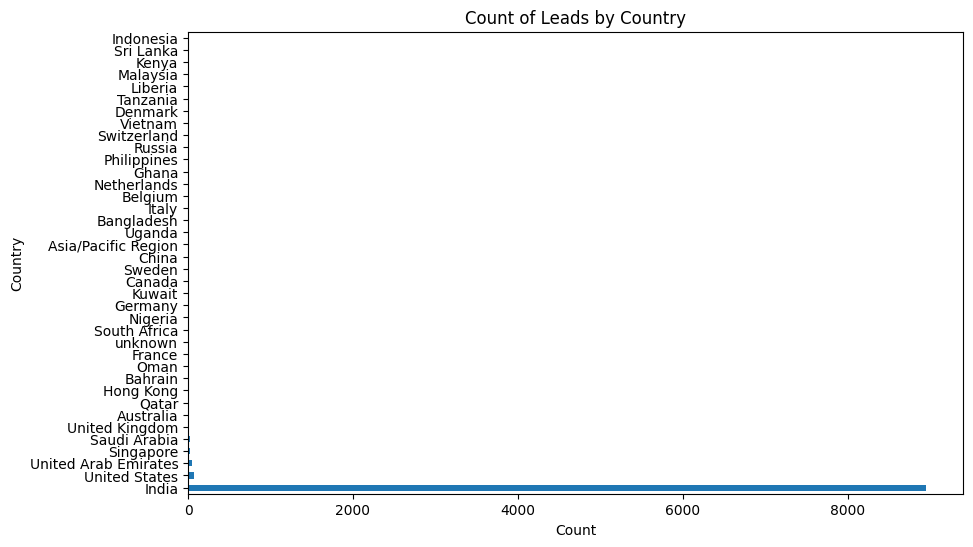

In [55]:
plt.figure(figsize=(10, 6))
lead_df["Country"].value_counts().plot.barh()
plt.title("Count of Leads by Country")
plt.xlabel("Count")
plt.ylabel("Country")

plt.show()

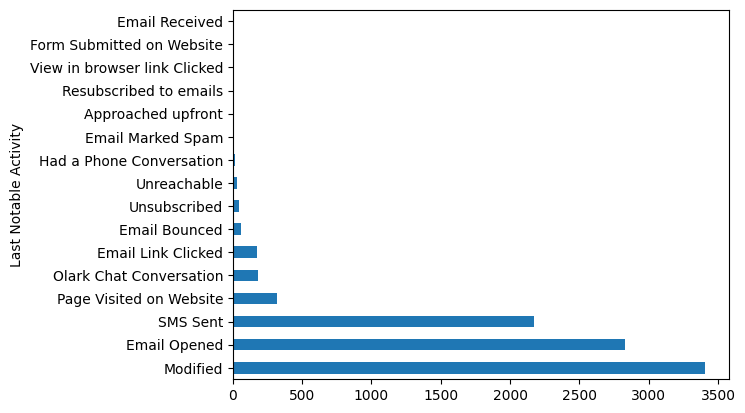

In [56]:
lead_df["Last Notable Activity"].value_counts().plot.barh()
plt.show()

In [57]:
#Bivariate analysis


<Figure size 1000x600 with 0 Axes>

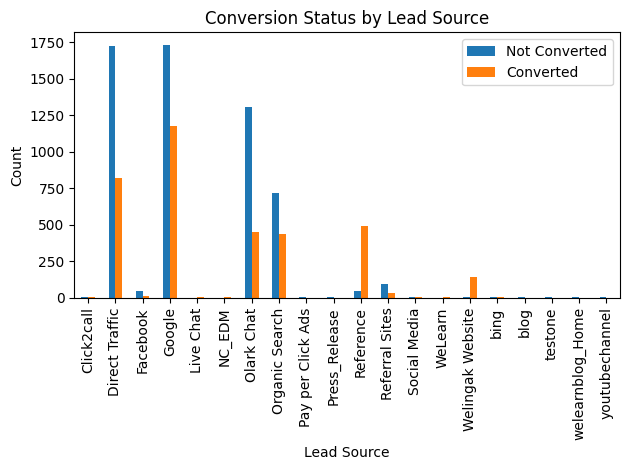

In [58]:
plt.figure(figsize=(10, 6))
graph1 = lead_df.groupby(by="Lead Source")["Converted"].value_counts()
graph1 = graph1.unstack().fillna(0)
graph1.plot.bar()  # Use the custom palette or palette name

plt.title("Conversion Status by Lead Source")
plt.xlabel("Lead Source")
plt.ylabel("Count")
plt.legend(["Not Converted", "Converted"])

plt.tight_layout()
plt.show()

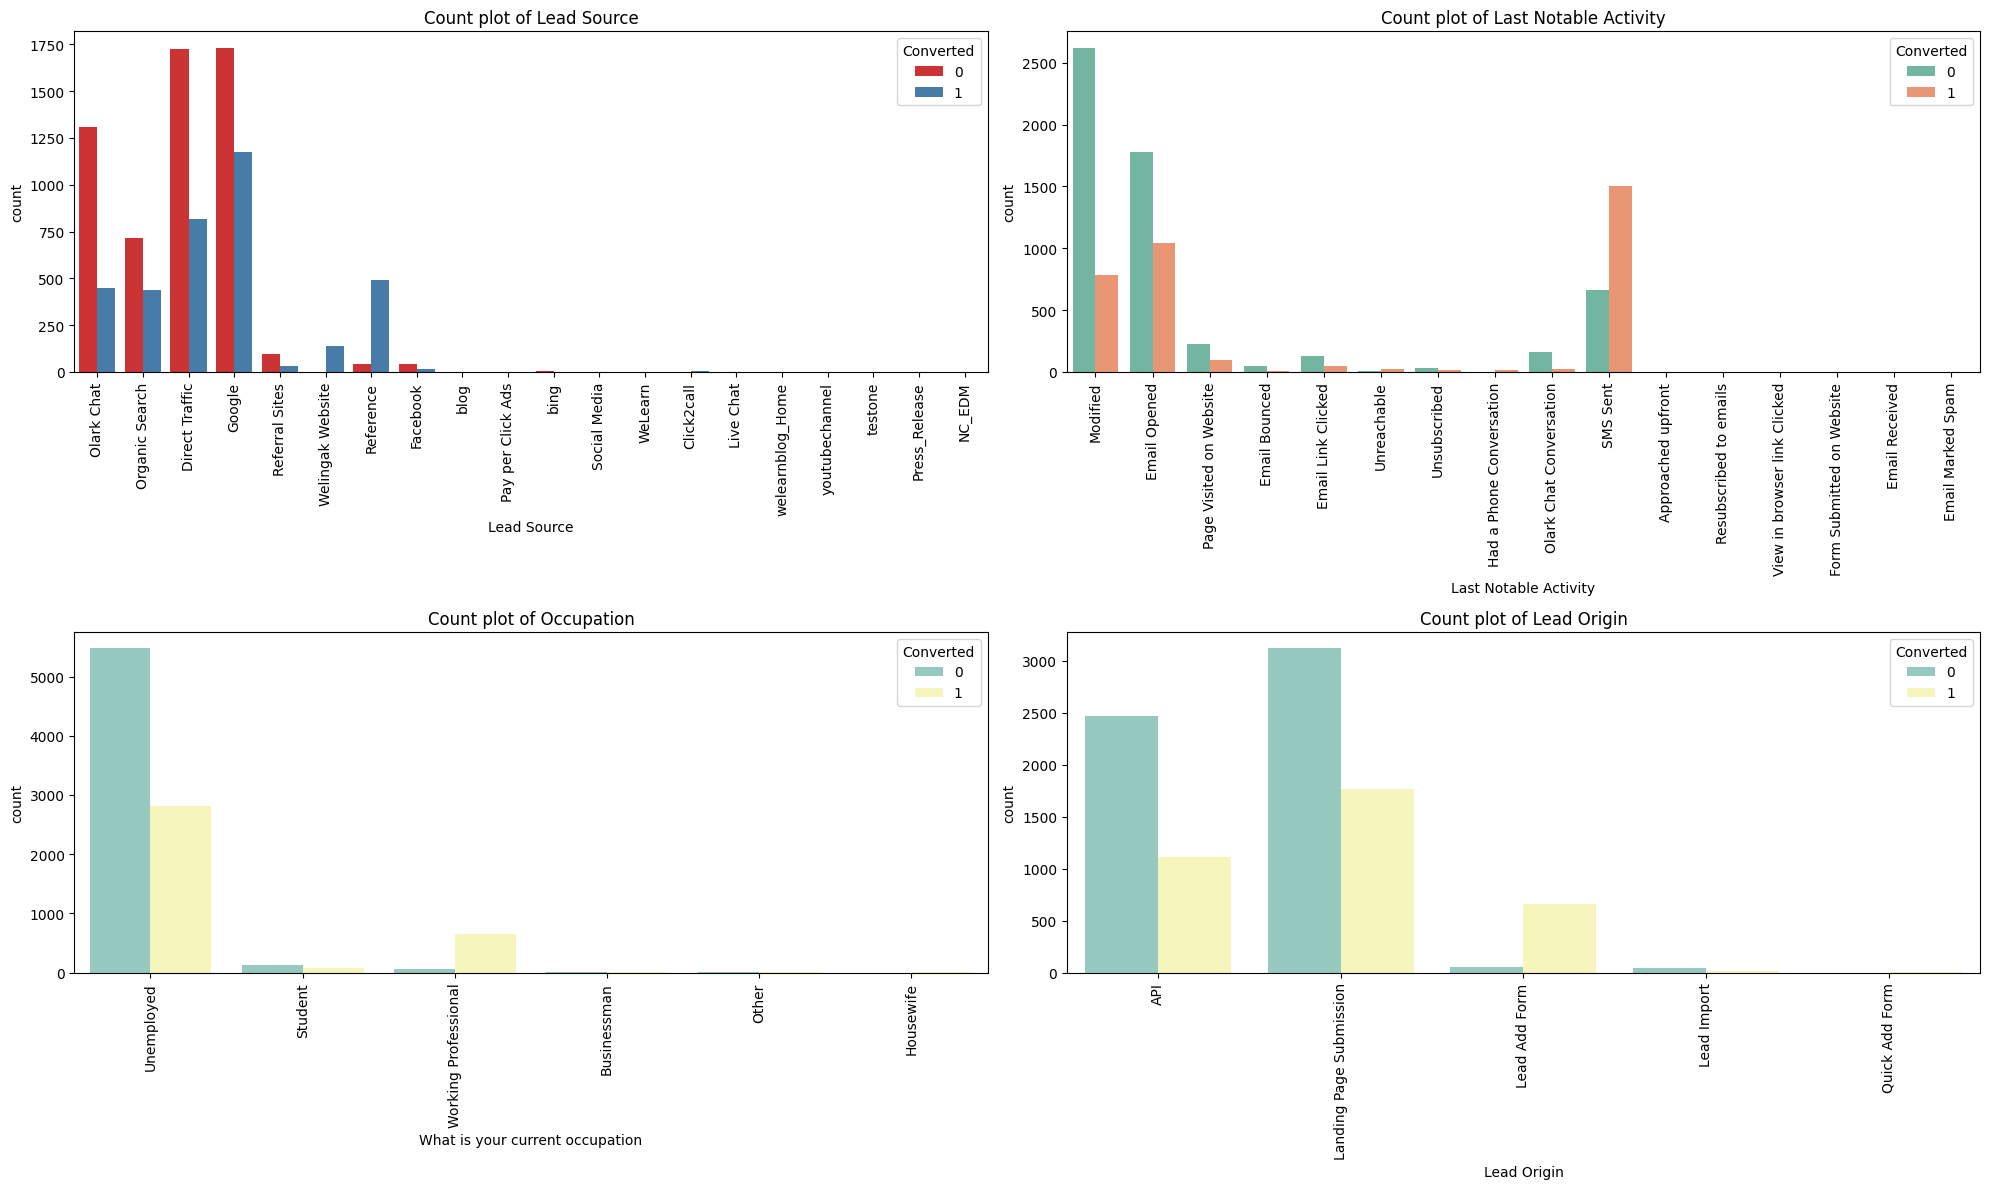

In [59]:

plt.figure(figsize=(20, 12))

plt.subplot(2, 2, 1)
ax1 = sns.countplot(x='Lead Source', data=lead_df, hue='Converted', palette='Set1')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
plt.title('Count plot of Lead Source')

plt.subplot(2, 2, 2)
ax2 = sns.countplot(x='Last Notable Activity', data=lead_df, hue='Converted', palette='Set2')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
plt.title('Count plot of Last Notable Activity')

plt.subplot(2, 2, 3)
ax3 = sns.countplot(x='What is your current occupation', data=lead_df, hue='Converted', palette='Set3')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=90)
plt.title('Count plot of Occupation')

plt.subplot(2, 2, 4)
ax4 = sns.countplot(x='Lead Origin', data=lead_df, hue='Converted', palette='Set3')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=90)
plt.title('Count plot of Lead Origin')

plt.tight_layout()
plt.show()

In [60]:
#multivariate analysis

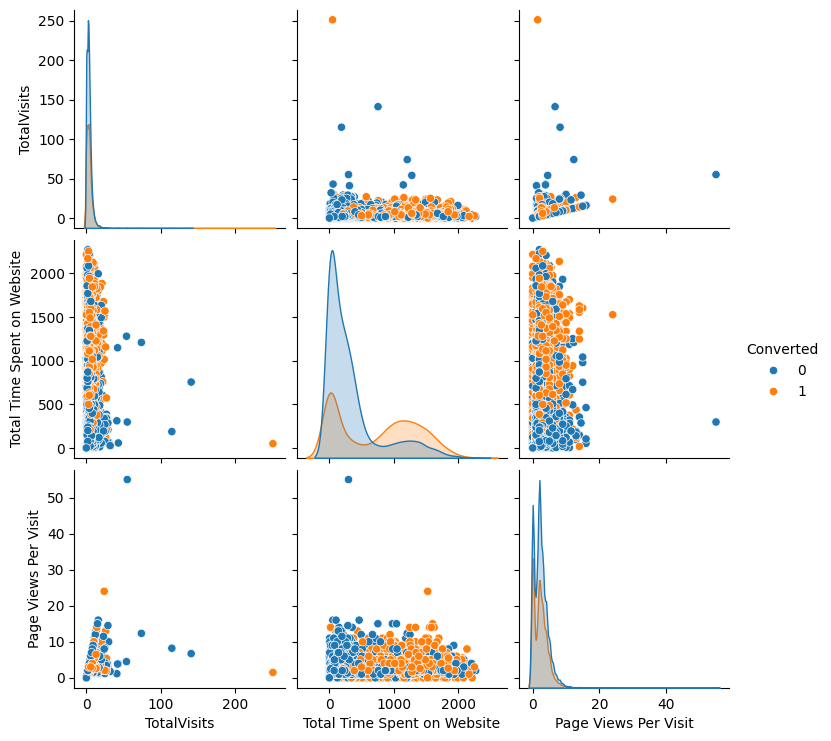

In [61]:
sns.pairplot(lead_df,hue = "Converted")

In [62]:
# changing yes and no to 1s and 0s

In [63]:
def binaryconvert(df):
    df = df.replace({'Yes': 1, 'No': 0})
    return df

In [64]:
lead_df1=binaryconvert(lead_df)

In [65]:
lead_df1.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,0,Modified
1,API,Organic Search,0,0,5.0,674,2.5,Email Opened,India,Unemployed,0,Email Opened
2,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,India,Student,1,Email Opened
3,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,Unreachable,India,Unemployed,0,Modified
4,Landing Page Submission,Google,0,1,2.0,1428,1.0,Converted to Lead,India,Unemployed,0,Modified


In [66]:
print(lead_df.dtypes)

Lead Origin                                object
Lead Source                                object
Do Not Email                               object
Converted                                   int64
TotalVisits                               float64
Total Time Spent on Website                 int64
Page Views Per Visit                      float64
Last Activity                              object
Country                                    object
What is your current occupation            object
A free copy of Mastering The Interview     object
Last Notable Activity                      object
dtype: object


In [67]:
#converting all categorical variables into dummies
#checking  percentages of different variables

100*(lead_df1['Lead Origin'].value_counts()/len(lead_df))

Lead Origin
Landing Page Submission    52.878788
API                        38.744589
Lead Add Form               7.770563
Lead Import                 0.595238
Quick Add Form              0.010823
Name: count, dtype: float64

In [68]:
#checking if the we can merge other small options into one
most_leads = 100*(lead_df1['Lead Source'].value_counts()/len(lead_df))<5
print(most_leads)

Lead Source
Google               False
Direct Traffic       False
Olark Chat           False
Organic Search       False
Reference            False
Welingak Website      True
Referral Sites        True
Facebook              True
bing                  True
Click2call            True
Social Media          True
Live Chat             True
Press_Release         True
Pay per Click Ads     True
blog                  True
WeLearn               True
welearnblog_Home      True
youtubechannel        True
testone               True
NC_EDM                True
Name: count, dtype: bool


In [69]:
#no need for any merging for this case

toconvert = lead_df1['Lead Source'].value_counts()[most_leads].index.tolist()

lead_df1.loc[lead_df1['Lead Source'].isin(toconvert), 'Lead Source'] = 'OtherLeads'


In [70]:
# merging all categories below 5% into OtherLeads
lead_df1['Lead Source'].value_counts()


Lead Source
Google            2909
Direct Traffic    2543
Olark Chat        1755
Organic Search    1154
Reference          534
OtherLeads         345
Name: count, dtype: int64

In [71]:
#to check the total percentage of the value counts

100*(lead_df1['Last Activity'].value_counts()/len(lead_df))

Last Activity
Email Opened                    38.311688
SMS Sent                        29.707792
Olark Chat Conversation         10.530303
Page Visited on Website          6.926407
Converted to Lead                4.632035
Email Bounced                    3.528139
Email Link Clicked               2.889610
Form Submitted on Website        1.255411
Unreachable                      1.006494
Unsubscribed                     0.660173
Had a Phone Conversation         0.324675
Approached upfront               0.097403
View in browser link Clicked     0.064935
Email Received                   0.021645
Email Marked Spam                0.021645
Visited Booth in Tradeshow       0.010823
Resubscribed to emails           0.010823
Name: count, dtype: float64

In [72]:
# merging categories that represent less than 5% of the observations into OtherLastActivity
toconvert = lead_df1['Last Activity'].value_counts()[100*(lead_df1['Last Activity'].value_counts()/len(lead_df)) < 5].index.tolist()

lead_df1.loc[lead_df1['Last Activity'].isin(toconvert), 'Last Activity'] = 'OtherLastActivity'


In [73]:

100*(lead_df1['Last Activity'].value_counts()/len(lead_df))

Last Activity
Email Opened               38.311688
SMS Sent                   29.707792
OtherLastActivity          14.523810
Olark Chat Conversation    10.530303
Page Visited on Website     6.926407
Name: count, dtype: float64

In [74]:

100*(lead_df1['Country'].value_counts()/len(lead_df))

Country
India                   96.893939
United States            0.746753
United Arab Emirates     0.573593
Singapore                0.259740
Saudi Arabia             0.227273
United Kingdom           0.162338
Australia                0.140693
Qatar                    0.108225
Hong Kong                0.075758
Bahrain                  0.075758
Oman                     0.064935
France                   0.064935
unknown                  0.054113
South Africa             0.043290
Nigeria                  0.043290
Germany                  0.043290
Kuwait                   0.043290
Canada                   0.043290
Sweden                   0.032468
China                    0.021645
Asia/Pacific Region      0.021645
Uganda                   0.021645
Bangladesh               0.021645
Italy                    0.021645
Belgium                  0.021645
Netherlands              0.021645
Ghana                    0.021645
Philippines              0.021645
Russia                   0.010823
Switze

In [75]:
toconvert = lead_df1['Country'].value_counts()[100*(lead_df1['Country'].value_counts()/len(lead_df)) < 1].index.tolist()

lead_df1.loc[lead_df1['Country'].isin(toconvert), 'Country'] = 'OtherCountries'

In [76]:
100*(lead_df1['Country'].value_counts()/len(lead_df))

Country
India             96.893939
OtherCountries     3.106061
Name: count, dtype: float64

In [77]:

100*(lead_df1['What is your current occupation'].value_counts()/len(lead_df))

What is your current occupation
Unemployed              89.718615
Working Professional     7.640693
Student                  2.272727
Other                    0.173160
Housewife                0.108225
Businessman              0.086580
Name: count, dtype: float64

In [78]:
toconvert = lead_df1['What is your current occupation'].value_counts()[100*(lead_df1['What is your current occupation'].value_counts()/len(lead_df)) < 1].index.tolist()

lead_df1.loc[lead_df1['What is your current occupation'].isin(toconvert), 'What is your current occupation'] = 'OtherOccupation'

In [79]:
100*(lead_df1['What is your current occupation'].value_counts()/len(lead_df))

What is your current occupation
Unemployed              89.718615
Working Professional     7.640693
Student                  2.272727
OtherOccupation          0.367965
Name: count, dtype: float64

In [80]:
lead_df1.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,0,Modified
1,API,Organic Search,0,0,5.0,674,2.5,Email Opened,India,Unemployed,0,Email Opened
2,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,India,Student,1,Email Opened
3,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,OtherLastActivity,India,Unemployed,0,Modified
4,Landing Page Submission,Google,0,1,2.0,1428,1.0,OtherLastActivity,India,Unemployed,0,Modified


In [81]:
100*(lead_df1['Last Notable Activity'].value_counts()/len(lead_df))

Last Notable Activity
Modified                        36.872294
Email Opened                    30.595238
SMS Sent                        23.506494
Page Visited on Website          3.441558
Olark Chat Conversation          1.980519
Email Link Clicked               1.872294
Email Bounced                    0.649351
Unsubscribed                     0.508658
Unreachable                      0.346320
Had a Phone Conversation         0.151515
Email Marked Spam                0.021645
Approached upfront               0.010823
Resubscribed to emails           0.010823
View in browser link Clicked     0.010823
Form Submitted on Website        0.010823
Email Received                   0.010823
Name: count, dtype: float64

In [82]:
# merging categories that represent less than 5% of the observations into OtherLastNotableActivity
toconvert = lead_df1['Last Notable Activity'].value_counts()[100*(lead_df1['Last Notable Activity'].value_counts()/len(lead_df)) < 5].index.tolist()

lead_df1.loc[lead_df1['Last Notable Activity'].isin(toconvert), 'Last Notable Activity'] = 'OtherLastNotableActivity'


In [83]:
100*(lead_df1['Last Notable Activity'].value_counts()/len(lead_df))

Last Notable Activity
Modified                    36.872294
Email Opened                30.595238
SMS Sent                    23.506494
OtherLastNotableActivity     9.025974
Name: count, dtype: float64

In [84]:
print(lead_df.dtypes)

Lead Origin                                object
Lead Source                                object
Do Not Email                               object
Converted                                   int64
TotalVisits                               float64
Total Time Spent on Website                 int64
Page Views Per Visit                      float64
Last Activity                              object
Country                                    object
What is your current occupation            object
A free copy of Mastering The Interview     object
Last Notable Activity                      object
dtype: object


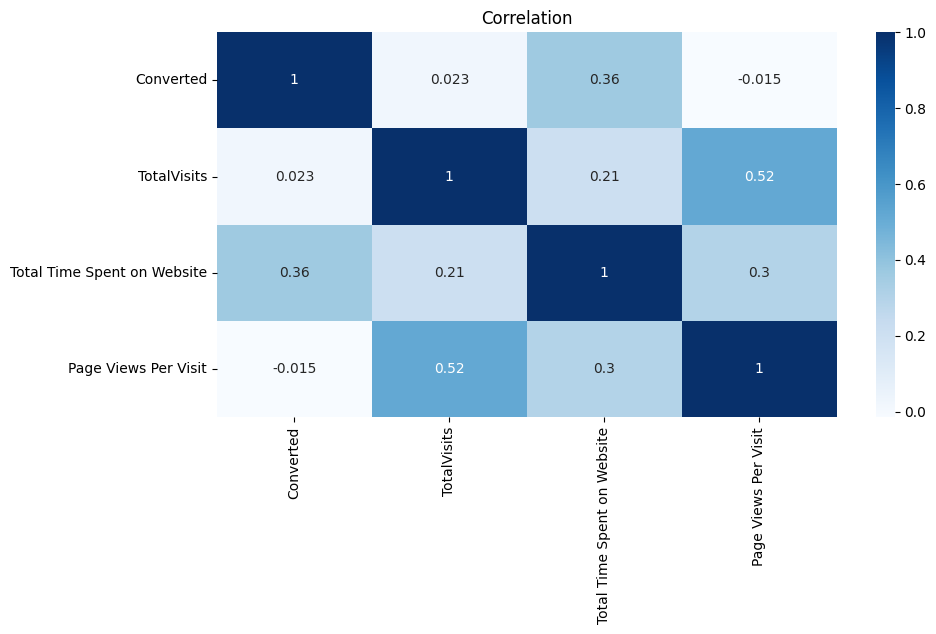

In [85]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    lead_df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation")
plt.show()

In [86]:
#####################

## Dummy Variable

In [87]:
#checking the dataset
lead_df1.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,What is your current occupation,A free copy of Mastering The Interview,Last Notable Activity
0,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,0,Modified
1,API,Organic Search,0,0,5.0,674,2.5,Email Opened,India,Unemployed,0,Email Opened
2,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,India,Student,1,Email Opened
3,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,OtherLastActivity,India,Unemployed,0,Modified
4,Landing Page Submission,Google,0,1,2.0,1428,1.0,OtherLastActivity,India,Unemployed,0,Modified


In [88]:
lead_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Lead Origin                             9240 non-null   object 
 1   Lead Source                             9240 non-null   object 
 2   Do Not Email                            9240 non-null   int64  
 3   Converted                               9240 non-null   int64  
 4   TotalVisits                             9240 non-null   float64
 5   Total Time Spent on Website             9240 non-null   int64  
 6   Page Views Per Visit                    9240 non-null   float64
 7   Last Activity                           9240 non-null   object 
 8   Country                                 9240 non-null   object 
 9   What is your current occupation         9240 non-null   object 
 10  A free copy of Mastering The Interview  9240 non-null   int6

In [89]:
#for convinience
lead_df1.rename(columns={'What is your current occupation':'Occupation'},inplace=True)

In [90]:
# converting categorical variables into dummy variables
# dtype=int keeps the dummy variables as numeric 0/1 values for later modelling.
dummy = pd.get_dummies(
    lead_df1[['Lead Origin','Lead Source','Last Activity','Country','Occupation','Last Notable Activity']],
    drop_first=True,
    dtype=int
)
dummy.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_OtherLeads,Lead Source_Reference,Last Activity_Olark Chat Conversation,Last Activity_OtherLastActivity,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Country_OtherCountries,Occupation_Student,Occupation_Unemployed,Occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_OtherLastNotableActivity,Last Notable Activity_SMS Sent
0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0
4,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0


In [91]:
dummy.head()

,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_OtherLeads,Lead Source_Reference,Last Activity_Olark Chat Conversation,Last Activity_OtherLastActivity,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Country_OtherCountries,Occupation_Student,Occupation_Unemployed,Occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_OtherLastNotableActivity,Last Notable Activity_SMS Sent
0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0
4,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0


In [92]:
#merging the two dataset one of which is original and one is dummy
lead_df1=pd.concat([lead_df1,dummy],axis=1)

In [93]:
lead_df1.head()

,Lead Origin,Lead Source,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Occupation,A free copy of Mastering The Interview,Last Notable Activity,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_OtherLeads,Lead Source_Reference,Last Activity_Olark Chat Conversation,Last Activity_OtherLastActivity,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Country_OtherCountries,Occupation_Student,Occupation_Unemployed,Occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_OtherLastNotableActivity,Last Notable Activity_SMS Sent
0,API,Olark Chat,0,0,0.0,0,0.0,Page Visited on Website,India,Unemployed,0,Modified,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
1,API,Organic Search,0,0,5.0,674,2.5,Email Opened,India,Unemployed,0,Email Opened,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,Landing Page Submission,Direct Traffic,0,1,2.0,1532,2.0,Email Opened,India,Student,1,Email Opened,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,Landing Page Submission,Direct Traffic,0,0,1.0,305,1.0,OtherLastActivity,India,Unemployed,0,Modified,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0
4,Landing Page Submission,Google,0,1,2.0,1428,1.0,OtherLastActivity,India,Unemployed,0,Modified,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0


In [94]:
lead_df1.shape

(9240, 32)

In [95]:
#dropping the original columns

to_be_dropped=['Lead Origin','Lead Source','Last Activity','Country','Occupation','Last Notable Activity']

In [96]:

lead_df1=lead_df1.drop(to_be_dropped ,axis=1)

In [97]:

lead_df1.head()

,Do Not Email,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_OtherLeads,Lead Source_Reference,Last Activity_Olark Chat Conversation,Last Activity_OtherLastActivity,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Country_OtherCountries,Occupation_Student,Occupation_Unemployed,Occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_OtherLastNotableActivity,Last Notable Activity_SMS Sent
0,0,0,0.0,0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0
1,0,0,5.0,674,2.5,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,1,2.0,1532,2.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,1.0,305,1.0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0
4,0,1,2.0,1428,1.0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0


In [98]:
lead_df1.shape

(9240, 26)

In [99]:
lead_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 26 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Do Not Email                                    9240 non-null   int64  
 1   Converted                                       9240 non-null   int64  
 2   TotalVisits                                     9240 non-null   float64
 3   Total Time Spent on Website                     9240 non-null   int64  
 4   Page Views Per Visit                            9240 non-null   float64
 5   A free copy of Mastering The Interview          9240 non-null   int64  
 6   Lead Origin_Landing Page Submission             9240 non-null   int64  
 7   Lead Origin_Lead Add Form                       9240 non-null   int64  
 8   Lead Origin_Lead Import                         9240 non-null   int64  
 9   Lead Origin_Quick Add Form               

# Train Test split

In [100]:
X = lead_df1.drop('Converted',axis=1)

y = lead_df1['Converted']

In [101]:
#spliting the data into train_test_split
from sklearn.model_selection import train_test_split



In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

In [103]:
print("X_train:", X_train.shape, "\ny_train:", y_train.shape)
print("X_test:", X_test.shape, "\ny_test:", y_test.shape)

X_train: (6468, 25) 
y_train: (6468,)
X_test: (2772, 25) 
y_test: (2772,)


In [104]:
#importing the library for standardscaler
from sklearn.preprocessing import StandardScaler

In [105]:
scaler = StandardScaler()

In [106]:
Num_cols = [
    'TotalVisits',
    'Total Time Spent on Website',
    'Page Views Per Visit'
]

# Fit the scaler only on the training data.
scaler.fit(X_train[Num_cols])

StandardScaler()

In [107]:
# Apply the training-set scaling parameters to the test data.
X_test[Num_cols] = scaler.transform(X_test[Num_cols])

In [108]:
# Apply the fitted scaler to the training data.
X_train[Num_cols] = scaler.transform(X_train[Num_cols])

In [109]:
X_train.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_OtherLeads,Lead Source_Reference,Last Activity_Olark Chat Conversation,Last Activity_OtherLastActivity,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Country_OtherCountries,Occupation_Student,Occupation_Unemployed,Occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_OtherLastNotableActivity,Last Notable Activity_SMS Sent
1871,0,-0.645678,-0.885371,-1.062143,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
6795,0,0.109111,0.005716,-0.452487,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3516,0,0.297808,-0.691418,0.083827,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
8105,0,0.297808,1.365219,1.229797,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1
3934,0,-0.645678,-0.885371,-1.062143,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0


In [110]:
LCR = round((sum(lead_df1['Converted'])/len(lead_df1['Converted'].index))*100, 3)
print('Lead Conversion Rate(LCR):', LCR)

Lead Conversion Rate(LCR): 38.539


In [111]:
# finding the correlation between the variables.
# A relatively high correlation between two predictors can indicate possible multicollinearity,
# so it will be checked further using VIF during model building.

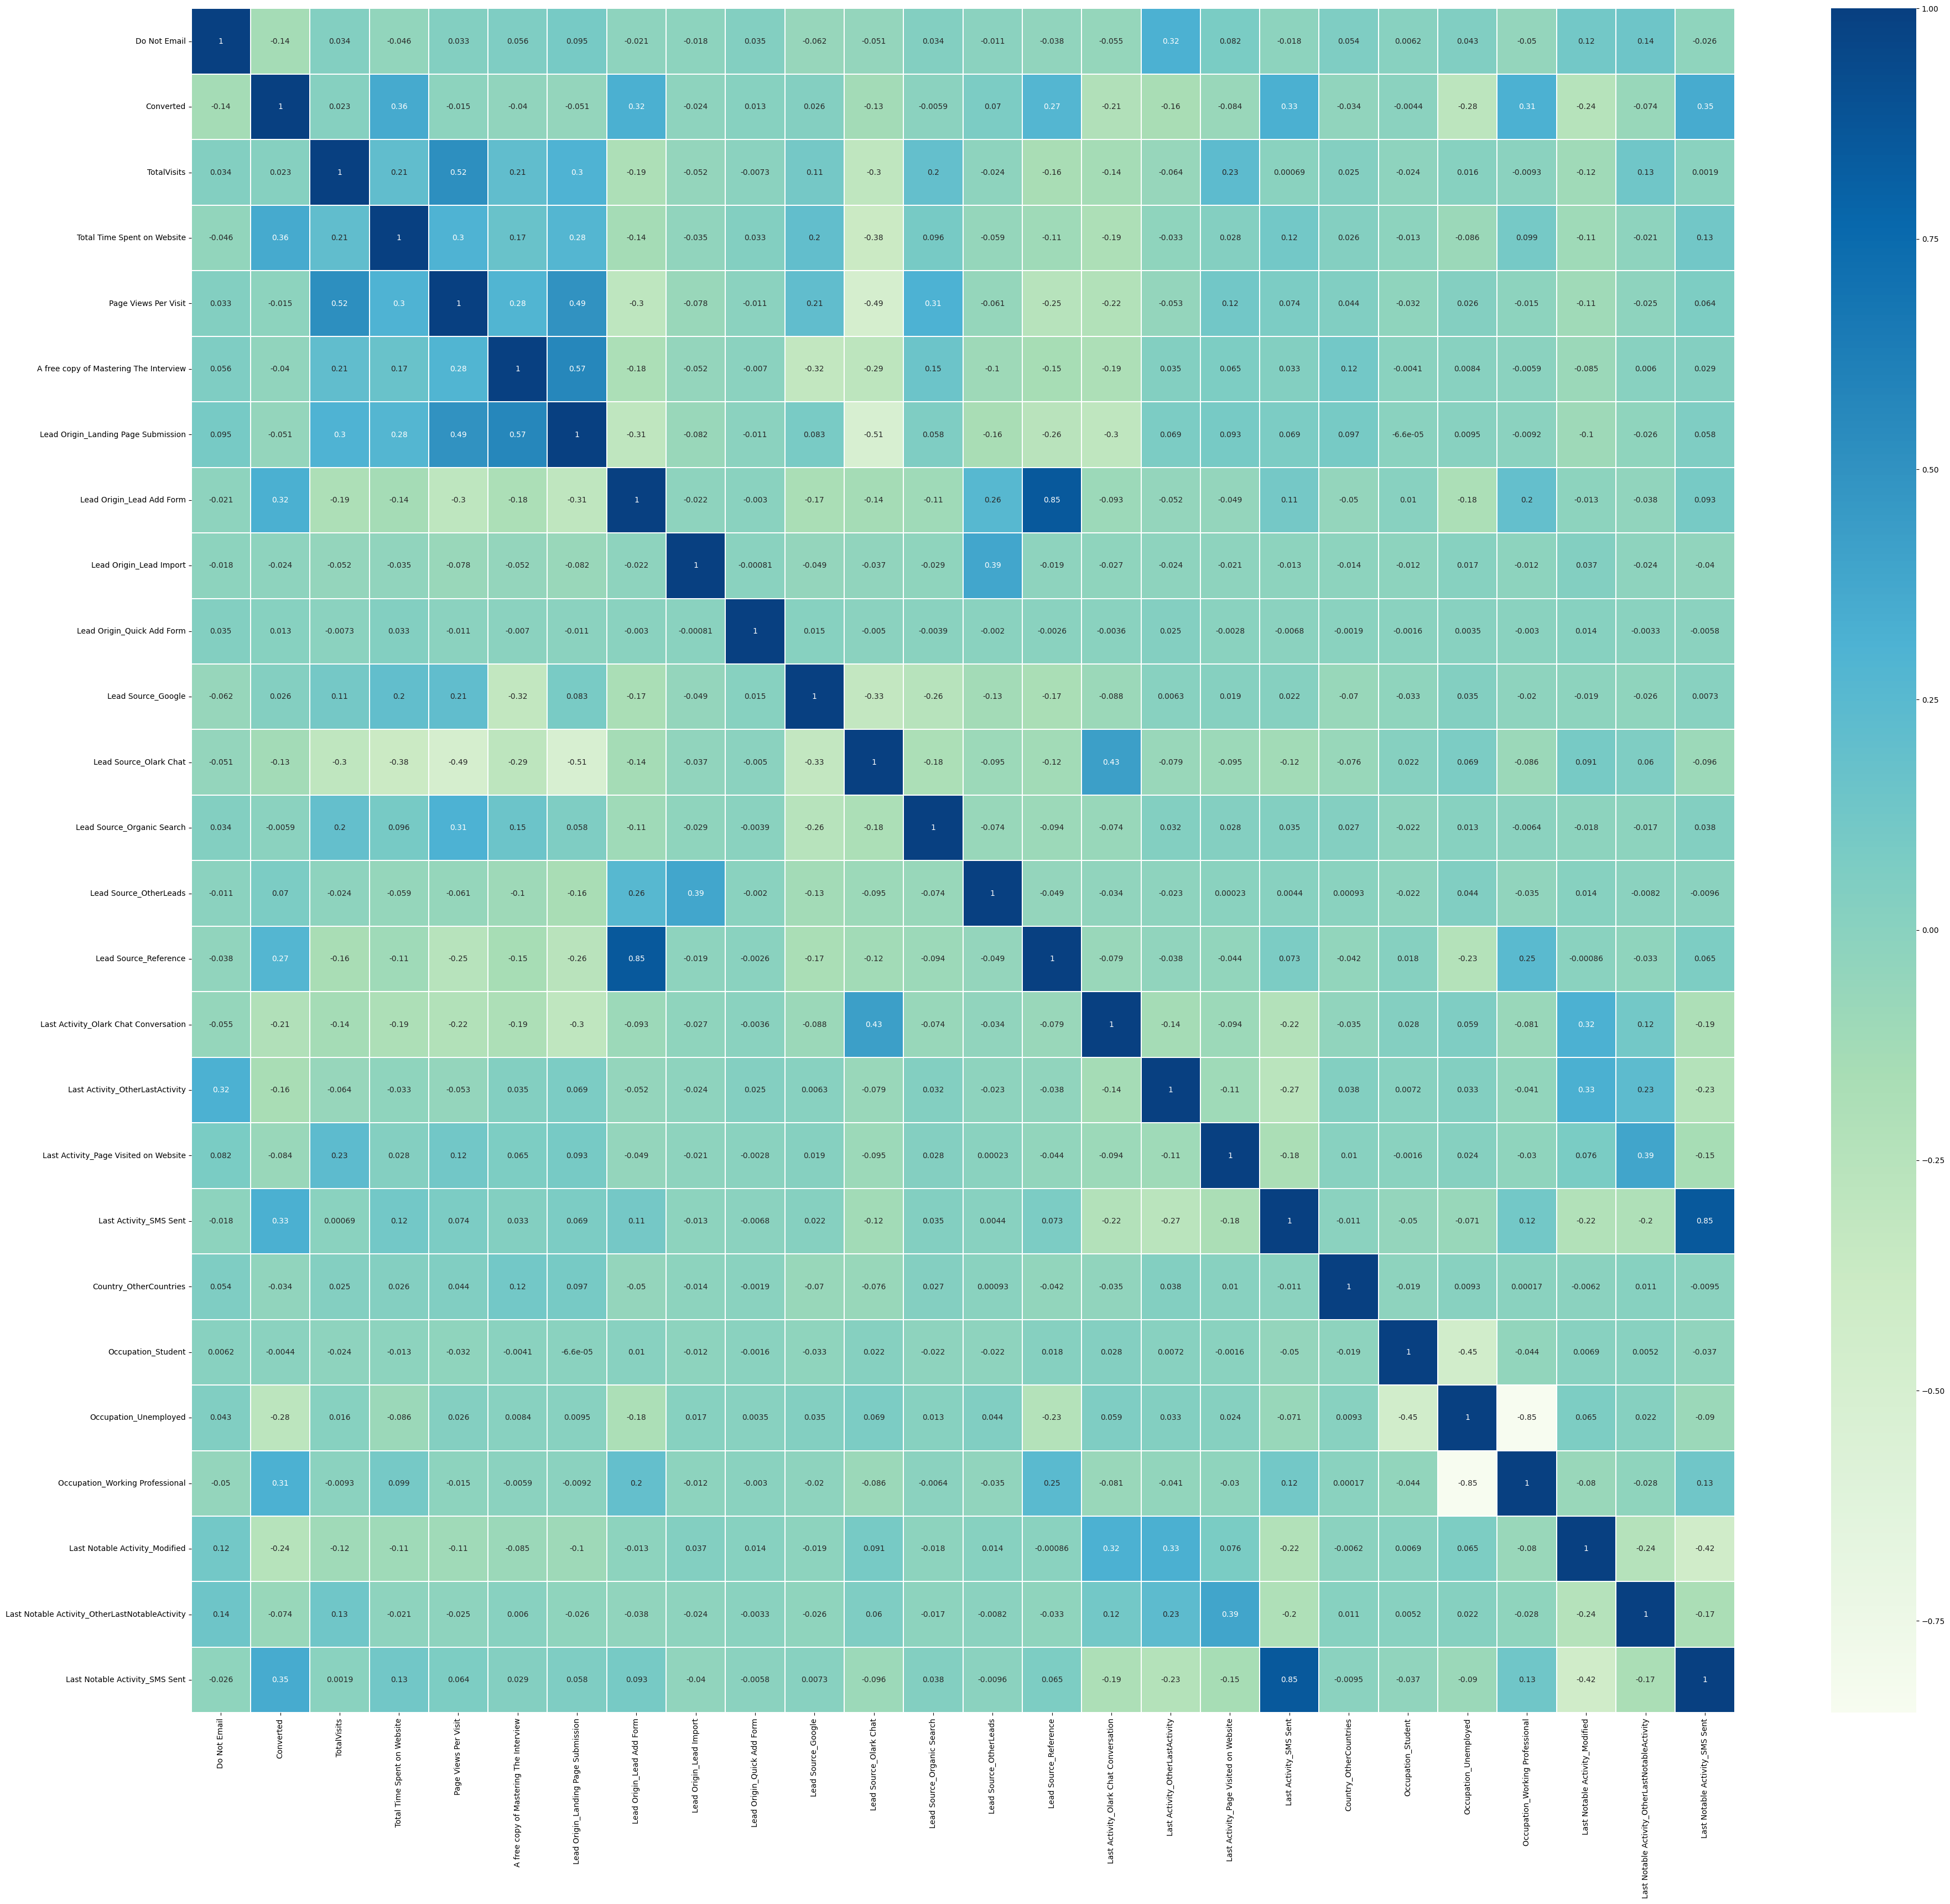

In [112]:
plt.figure(figsize = (45, 40))
sns.heatmap(lead_df1.corr(numeric_only=True), linewidths=0.02, cmap="GnBu", annot=True)
plt.show()


The dummy variables `Last Notable Activity_SMS Sent` and `Lead Source_Reference` have a relatively high correlation (approximately 0.85). This indicates potential redundancy between the two predictors. One of them is removed to reduce multicollinearity, and VIF is checked during model building as an additional diagnostic.

In [113]:
X_test = X_test.drop(
    ['Last Notable Activity_SMS Sent', 'Lead Source_Reference'],
    axis=1
)

X_train = X_train.drop(
    ['Last Notable Activity_SMS Sent', 'Lead Source_Reference'],
    axis=1
)

# Model Building

In [114]:
#using RFE we will build our model

In [115]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
rfe = RFE(estimator=logreg, n_features_to_select=15)
rfe.fit(X_train, y_train)

RFE(estimator=LogisticRegression(), n_features_to_select=15)

In [116]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('Do Not Email', True, 1),
 ('TotalVisits', False, 3),
 ('Total Time Spent on Website', True, 1),
 ('Page Views Per Visit', False, 5),
 ('A free copy of Mastering The Interview', False, 8),
 ('Lead Origin_Landing Page Submission', True, 1),
 ('Lead Origin_Lead Add Form', True, 1),
 ('Lead Origin_Lead Import', True, 1),
 ('Lead Origin_Quick Add Form', False, 7),
 ('Lead Source_Google', True, 1),
 ('Lead Source_Olark Chat', True, 1),
 ('Lead Source_Organic Search', False, 4),
 ('Lead Source_OtherLeads', True, 1),
 ('Last Activity_Olark Chat Conversation', True, 1),
 ('Last Activity_OtherLastActivity', False, 2),
 ('Last Activity_Page Visited on Website', True, 1),
 ('Last Activity_SMS Sent', True, 1),
 ('Country_OtherCountries', False, 6),
 ('Occupation_Student', True, 1),
 ('Occupation_Unemployed', True, 1),
 ('Occupation_Working Professional', True, 1),
 ('Last Notable Activity_Modified', True, 1),
 ('Last Notable Activity_OtherLastNotableActivity', False, 9)]

# Model1

In [117]:
col = X_train.columns[rfe.support_]
col

Index(['Do Not Email', 'Total Time Spent on Website',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form',
       'Lead Origin_Lead Import', 'Lead Source_Google',
       'Lead Source_Olark Chat', 'Lead Source_OtherLeads',
       'Last Activity_Olark Chat Conversation',
       'Last Activity_Page Visited on Website', 'Last Activity_SMS Sent',
       'Occupation_Student', 'Occupation_Unemployed',
       'Occupation_Working Professional', 'Last Notable Activity_Modified'],
      dtype='object')

In [118]:
X_train.columns[~rfe.support_]

Index(['TotalVisits', 'Page Views Per Visit',
       'A free copy of Mastering The Interview', 'Lead Origin_Quick Add Form',
       'Lead Source_Organic Search', 'Last Activity_OtherLastActivity',
       'Country_OtherCountries',
       'Last Notable Activity_OtherLastNotableActivity'],
      dtype='object')

In [119]:
#variables selected by RFE
X_train_rfe = X_train[col]

In [120]:
# we will define a VIF calculator so that we can check multicollinearity at any time

In [121]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def VIF_calculator(inp0):
    vif = pd.DataFrame()
    vif['Features'] = inp0.columns
    vif['VIF'] = [variance_inflation_factor(inp0.values, i) for i in range(inp0.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    return vif

In [122]:
print(X_train_rfe.dtypes)

Do Not Email                               int64
Total Time Spent on Website              float64
Lead Origin_Landing Page Submission        int64
Lead Origin_Lead Add Form                  int64
Lead Origin_Lead Import                    int64
Lead Source_Google                         int64
Lead Source_Olark Chat                     int64
Lead Source_OtherLeads                     int64
Last Activity_Olark Chat Conversation      int64
Last Activity_Page Visited on Website      int64
Last Activity_SMS Sent                     int64
Occupation_Student                         int64
Occupation_Unemployed                      int64
Occupation_Working Professional            int64
Last Notable Activity_Modified             int64
dtype: object


In [123]:
X_train_rfe = X_train_rfe.astype(float)

VIF_calculator(X_train_rfe)

,Features,VIF
12,Occupation_Unemployed,8.48
2,Lead Origin_Landing Page Submission,4.05
6,Lead Source_Olark Chat,2.85
5,Lead Source_Google,1.94
14,Last Notable Activity_Modified,1.87
13,Occupation_Working Professional,1.73
3,Lead Origin_Lead Add Form,1.71
10,Last Activity_SMS Sent,1.65
8,Last Activity_Olark Chat Conversation,1.59
7,Lead Source_OtherLeads,1.34


In [124]:
# VIF has already been calculated for Model 1 above; no additional calculation is needed here.

In [125]:
import statsmodels.api as sm  
X_train_sm = sm.add_constant(X_train_rfe)

In [126]:
#model fitting
mod_1 = sm.GLM(y_train,X_train_sm,family=sm.families.Binomial()).fit()
mod_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6452
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2706.6
Date:                Sun, 04 Oct 2026   Deviance:                       5413.2
Time:                        01:12:02   Pearson chi2:                 7.02e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3889
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.2437      0.533      0.457      0.647      -0.801       1.288
Do Not Email                             -1.2185      0.166     -7.333      0.000      -1.544      -0.893
Total Time Spent on Website               1.0849      0.039     27.690      0.000       1.008       1.162
Lead Origin_Landing Page Submission      -0.1929      0.092     -2.094      0.036      -0.373      -0.012
Lead Origin_Lead Add Form                 3.8319      0.199     19.277      0.000       3.442       4.222
Lead Origin_Lead Import                  -0.3792      0.556     -0.682      0.495      -1.469       0.710
Lead Source_Google                        0.3009      0.081      3.700      0.000       0.142       0.460
Lead Source_Olark Chat                    1.1369      0.132      8.645      0.000       0.879       1.395
Lead Source_OtherLeads                    0.4632      0.229      2.023      0.043       0.014       0.912
Last Activity_Olark Chat Conversation    -0.9739      0.171     -5.710      0.000      -1.308      -0.640
Last Activity_Page Visited on Website    -0.2395      0.146     -1.640      0.101      -0.526       0.047
Last Activity_SMS Sent                    1.2106      0.075     16.164      0.000       1.064       1.357
Occupation_Student                       -1.0634      0.575     -1.849      0.064      -2.191       0.064
Occupation_Unemployed                    -1.4402      0.527     -2.733      0.006      -2.473      -0.407
Occupation_Working Professional           1.3846      0.557      2.488      0.013       0.294       2.475
Last Notable Activity_Modified           -0.8995      0.080    -11.247      0.000      -1.056      -0.743
=========================================================================================================
"""

In [127]:
mod_1.params

const                                    0.243725
Do Not Email                            -1.218503
Total Time Spent on Website              1.084888
Lead Origin_Landing Page Submission     -0.192872
Lead Origin_Lead Add Form                3.831902
Lead Origin_Lead Import                 -0.379164
Lead Source_Google                       0.300910
Lead Source_Olark Chat                   1.136854
Lead Source_OtherLeads                   0.463202
Last Activity_Olark Chat Conversation   -0.973875
Last Activity_Page Visited on Website   -0.239501
Last Activity_SMS Sent                   1.210576
Occupation_Student                      -1.063386
Occupation_Unemployed                   -1.440152
Occupation_Working Professional          1.384628
Last Notable Activity_Modified          -0.899452
dtype: float64

In [128]:
print(col)

Index(['Do Not Email', 'Total Time Spent on Website',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form',
       'Lead Origin_Lead Import', 'Lead Source_Google',
       'Lead Source_Olark Chat', 'Lead Source_OtherLeads',
       'Last Activity_Olark Chat Conversation',
       'Last Activity_Page Visited on Website', 'Last Activity_SMS Sent',
       'Occupation_Student', 'Occupation_Unemployed',
       'Occupation_Working Professional', 'Last Notable Activity_Modified'],
      dtype='object')


# Model2

In [129]:
X_train_rfe = X_train[col]

In [130]:
X_train_rfe = X_train_rfe.astype(float)

In [131]:
VIF_calculator(X_train_rfe)

,Features,VIF
12,Occupation_Unemployed,8.48
2,Lead Origin_Landing Page Submission,4.05
6,Lead Source_Olark Chat,2.85
5,Lead Source_Google,1.94
14,Last Notable Activity_Modified,1.87
13,Occupation_Working Professional,1.73
3,Lead Origin_Lead Add Form,1.71
10,Last Activity_SMS Sent,1.65
8,Last Activity_Olark Chat Conversation,1.59
7,Lead Source_OtherLeads,1.34


In [132]:
#model fitting
X_train_sm = sm.add_constant(X_train_rfe)
mod_2 = sm.GLM(y_train,X_train_sm,family=sm.families.Binomial()).fit()
mod_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6452
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2706.6
Date:                Sun, 04 Oct 2026   Deviance:                       5413.2
Time:                        01:12:02   Pearson chi2:                 7.02e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3889
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.2437      0.533      0.457      0.647      -0.801       1.288
Do Not Email                             -1.2185      0.166     -7.333      0.000      -1.544      -0.893
Total Time Spent on Website               1.0849      0.039     27.690      0.000       1.008       1.162
Lead Origin_Landing Page Submission      -0.1929      0.092     -2.094      0.036      -0.373      -0.012
Lead Origin_Lead Add Form                 3.8319      0.199     19.277      0.000       3.442       4.222
Lead Origin_Lead Import                  -0.3792      0.556     -0.682      0.495      -1.469       0.710
Lead Source_Google                        0.3009      0.081      3.700      0.000       0.142       0.460
Lead Source_Olark Chat                    1.1369      0.132      8.645      0.000       0.879       1.395
Lead Source_OtherLeads                    0.4632      0.229      2.023      0.043       0.014       0.912
Last Activity_Olark Chat Conversation    -0.9739      0.171     -5.710      0.000      -1.308      -0.640
Last Activity_Page Visited on Website    -0.2395      0.146     -1.640      0.101      -0.526       0.047
Last Activity_SMS Sent                    1.2106      0.075     16.164      0.000       1.064       1.357
Occupation_Student                       -1.0634      0.575     -1.849      0.064      -2.191       0.064
Occupation_Unemployed                    -1.4402      0.527     -2.733      0.006      -2.473      -0.407
Occupation_Working Professional           1.3846      0.557      2.488      0.013       0.294       2.475
Last Notable Activity_Modified           -0.8995      0.080    -11.247      0.000      -1.056      -0.743
=========================================================================================================
"""

# Model3

In [133]:
#dropping another variable
col=col.drop('Lead Origin_Lead Import')
col

Index(['Do Not Email', 'Total Time Spent on Website',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form',
       'Lead Source_Google', 'Lead Source_Olark Chat',
       'Lead Source_OtherLeads', 'Last Activity_Olark Chat Conversation',
       'Last Activity_Page Visited on Website', 'Last Activity_SMS Sent',
       'Occupation_Student', 'Occupation_Unemployed',
       'Occupation_Working Professional', 'Last Notable Activity_Modified'],
      dtype='object')

In [134]:
X_train_rfe = X_train[col]

In [135]:
X_train_rfe = X_train_rfe.astype(float)

In [136]:
VIF_calculator(X_train_rfe)

,Features,VIF
11,Occupation_Unemployed,8.40
2,Lead Origin_Landing Page Submission,4.02
5,Lead Source_Olark Chat,2.84
4,Lead Source_Google,1.94
13,Last Notable Activity_Modified,1.86
12,Occupation_Working Professional,1.72
3,Lead Origin_Lead Add Form,1.67
9,Last Activity_SMS Sent,1.65
7,Last Activity_Olark Chat Conversation,1.59
1,Total Time Spent on Website,1.25


In [137]:
#model fitting
X_train_sm = sm.add_constant(X_train_rfe)
mod_3 = sm.GLM(y_train,X_train_sm,family=sm.families.Binomial()).fit()
mod_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6453
Model Family:                Binomial   Df Model:                           14
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2706.9
Date:                Sun, 04 Oct 2026   Deviance:                       5413.7
Time:                        01:12:02   Pearson chi2:                 7.04e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3888
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.2381      0.533      0.447      0.655      -0.807       1.283
Do Not Email                             -1.2165      0.166     -7.322      0.000      -1.542      -0.891
Total Time Spent on Website               1.0859      0.039     27.729      0.000       1.009       1.163
Lead Origin_Landing Page Submission      -0.1880      0.092     -2.047      0.041      -0.368      -0.008
Lead Origin_Lead Add Form                 3.8497      0.197     19.517      0.000       3.463       4.236
Lead Source_Google                        0.3028      0.081      3.724      0.000       0.143       0.462
Lead Source_Olark Chat                    1.1426      0.131      8.702      0.000       0.885       1.400
Lead Source_OtherLeads                    0.4031      0.212      1.902      0.057      -0.012       0.818
Last Activity_Olark Chat Conversation    -0.9698      0.170     -5.690      0.000      -1.304      -0.636
Last Activity_Page Visited on Website    -0.2367      0.146     -1.621      0.105      -0.523       0.049
Last Activity_SMS Sent                    1.2103      0.075     16.164      0.000       1.064       1.357
Occupation_Student                       -1.0626      0.575     -1.847      0.065      -2.190       0.065
Occupation_Unemployed                    -1.4396      0.527     -2.731      0.006      -2.473      -0.406
Occupation_Working Professional           1.3841      0.557      2.486      0.013       0.293       2.475
Last Notable Activity_Modified           -0.9019      0.080    -11.288      0.000      -1.058      -0.745
=========================================================================================================
"""

# Model 4

In [138]:
#dropping variable
col=col.drop('Last Activity_Page Visited on Website')
col

Index(['Do Not Email', 'Total Time Spent on Website',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form',
       'Lead Source_Google', 'Lead Source_Olark Chat',
       'Lead Source_OtherLeads', 'Last Activity_Olark Chat Conversation',
       'Last Activity_SMS Sent', 'Occupation_Student', 'Occupation_Unemployed',
       'Occupation_Working Professional', 'Last Notable Activity_Modified'],
      dtype='object')

In [139]:
X_train_rfe = X_train[col]

In [140]:
X_train_rfe = X_train_rfe.astype(float)

In [141]:
VIF_calculator(X_train_rfe)

,Features,VIF
10,Occupation_Unemployed,8.25
2,Lead Origin_Landing Page Submission,4.01
5,Lead Source_Olark Chat,2.83
4,Lead Source_Google,1.93
12,Last Notable Activity_Modified,1.85
11,Occupation_Working Professional,1.71
3,Lead Origin_Lead Add Form,1.67
8,Last Activity_SMS Sent,1.59
7,Last Activity_Olark Chat Conversation,1.57
1,Total Time Spent on Website,1.25


In [142]:
#model4 fitting
X_train_sm = sm.add_constant(X_train_rfe)
mod_4 = sm.GLM(y_train,X_train_sm,family=sm.families.Binomial()).fit()
mod_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6454
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2708.2
Date:                Sun, 04 Oct 2026   Deviance:                       5416.4
Time:                        01:12:03   Pearson chi2:                 7.02e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3886
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.1826      0.529      0.345      0.730      -0.855       1.220
Do Not Email                             -1.2263      0.166     -7.390      0.000      -1.552      -0.901
Total Time Spent on Website               1.0843      0.039     27.728      0.000       1.008       1.161
Lead Origin_Landing Page Submission      -0.1885      0.092     -2.053      0.040      -0.368      -0.009
Lead Origin_Lead Add Form                 3.8638      0.197     19.595      0.000       3.477       4.250
Lead Source_Google                        0.3034      0.081      3.735      0.000       0.144       0.463
Lead Source_Olark Chat                    1.1493      0.131      8.753      0.000       0.892       1.407
Lead Source_OtherLeads                    0.4042      0.212      1.906      0.057      -0.012       0.820
Last Activity_Olark Chat Conversation    -0.9443      0.170     -5.561      0.000      -1.277      -0.612
Last Activity_SMS Sent                    1.2349      0.073     16.811      0.000       1.091       1.379
Occupation_Student                       -1.0293      0.573     -1.797      0.072      -2.152       0.093
Occupation_Unemployed                    -1.4073      0.524     -2.686      0.007      -2.434      -0.380
Occupation_Working Professional           1.4170      0.554      2.559      0.010       0.332       2.502
Last Notable Activity_Modified           -0.9120      0.080    -11.451      0.000      -1.068      -0.756
=========================================================================================================
"""

# Model 5

In [143]:
#dropping variable 
col=col.drop('Occupation_Student')
col

Index(['Do Not Email', 'Total Time Spent on Website',
       'Lead Origin_Landing Page Submission', 'Lead Origin_Lead Add Form',
       'Lead Source_Google', 'Lead Source_Olark Chat',
       'Lead Source_OtherLeads', 'Last Activity_Olark Chat Conversation',
       'Last Activity_SMS Sent', 'Occupation_Unemployed',
       'Occupation_Working Professional', 'Last Notable Activity_Modified'],
      dtype='object')

In [144]:
X_train_rfe = X_train[col]

In [145]:
X_train_rfe = X_train_rfe.astype(float)

In [146]:
VIF_calculator(X_train_rfe)

,Features,VIF
9,Occupation_Unemployed,7.23
2,Lead Origin_Landing Page Submission,3.61
5,Lead Source_Olark Chat,2.62
4,Lead Source_Google,1.86
11,Last Notable Activity_Modified,1.83
10,Occupation_Working Professional,1.62
3,Lead Origin_Lead Add Form,1.59
8,Last Activity_SMS Sent,1.58
7,Last Activity_Olark Chat Conversation,1.56
1,Total Time Spent on Website,1.25


In [147]:
#fitting model
X_train_sm = sm.add_constant(X_train_rfe)
mod_5 = sm.GLM(y_train,X_train_sm,family=sm.families.Binomial()).fit()
mod_5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6455
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2709.8
Date:                Sun, 04 Oct 2026   Deviance:                       5419.7
Time:                        01:12:03   Pearson chi2:                 7.03e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3883
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -0.6705      0.230     -2.914      0.004      -1.121      -0.220
Do Not Email                             -1.2257      0.166     -7.397      0.000      -1.550      -0.901
Total Time Spent on Website               1.0856      0.039     27.767      0.000       1.009       1.162
Lead Origin_Landing Page Submission      -0.1902      0.092     -2.072      0.038      -0.370      -0.010
Lead Origin_Lead Add Form                 3.8671      0.197     19.615      0.000       3.481       4.253
Lead Source_Google                        0.3002      0.081      3.697      0.000       0.141       0.459
Lead Source_Olark Chat                    1.1417      0.131      8.702      0.000       0.885       1.399
Lead Source_OtherLeads                    0.3979      0.212      1.875      0.061      -0.018       0.814
Last Activity_Olark Chat Conversation    -0.9440      0.170     -5.563      0.000      -1.277      -0.611
Last Activity_SMS Sent                    1.2323      0.073     16.772      0.000       1.088       1.376
Occupation_Unemployed                    -0.5511      0.214     -2.570      0.010      -0.971      -0.131
Occupation_Working Professional           2.2722      0.280      8.107      0.000       1.723       2.822
Last Notable Activity_Modified           -0.9077      0.080    -11.412      0.000      -1.064      -0.752
=========================================================================================================
"""

## The final model was reviewed using both VIF and coefficient p-values. Variables with relatively high VIF or weak statistical evidence were considered for removal during model refinement. The final set of predictors does not show severe multicollinearity based on the VIF values examined.

# Model Evaluation

In [148]:
# Getting the Predicted values on the train set
y_train_pred = mod_5.predict(X_train_sm)
y_train_pred[:10]

1871    0.260941
6795    0.196936
3516    0.303534
8105    0.832412
3934    0.124689
4844    0.990680
3297    0.099385
8071    0.986310
987     0.254708
7423    0.920887
dtype: float64

In [149]:
y_train_pred = y_train_pred.values.reshape(-1)
y_train_pred[:10]

array([0.26094142, 0.19693637, 0.30353384, 0.83241222, 0.12468903,
       0.99067958, 0.09938527, 0.98630977, 0.25470815, 0.92088716])

In [150]:
y_train_pred_final = pd.DataFrame({'Converted':y_train.values, 'Converted_prob':y_train_pred})
y_train_pred_final['Prospect ID'] = y_train.index
y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID
0,0,0.260941,1871
1,0,0.196936,6795
2,0,0.303534,3516
3,0,0.832412,8105
4,0,0.124689,3934


In [151]:
y_train_pred_final['Predicted'] = y_train_pred_final.Converted_prob.map(lambda x: 1 if x > 0.5 else 0)

# Let's see the head
y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID,Predicted
0,0,0.260941,1871,0
1,0,0.196936,6795,0
2,0,0.303534,3516,0
3,0,0.832412,8105,1
4,0,0.124689,3934,0


In [152]:
from sklearn import metrics

# Confusion matrix 
confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.Predicted )
print(confusion)

[[3554  448]
 [ 744 1722]]


In [153]:
print(metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.Predicted))

0.8157081014223871


In [154]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [155]:
# Let's see the accuracy of our logistic regression model
round((TN+TP) / float(TN+TP+FN+FP), 4)

0.8157

In [156]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

0.6982968369829684

In [157]:
# Let us calculate specificity
TN / float(TN+FP)

0.888055972013993

In [158]:
# Calculate False Postive Rate - predicting conversion when customer does not have convert
print(FP/ float(TN+FP))

0.111944027986007


In [159]:
# positive predictive value 
print (TP / float(TP+FP))

0.7935483870967742


In [160]:
# Negative predictive value
print (TN / float(TN+ FN))

0.8268962308050256


The training-set performance shown above is based on the 0.5 probability cutoff. Accuracy, sensitivity and specificity are calculated from the confusion matrix rather than being manually entered.

## ROC CURVE


In [161]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [162]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_final.Converted, y_train_pred_final.Converted_prob, drop_intermediate = False )

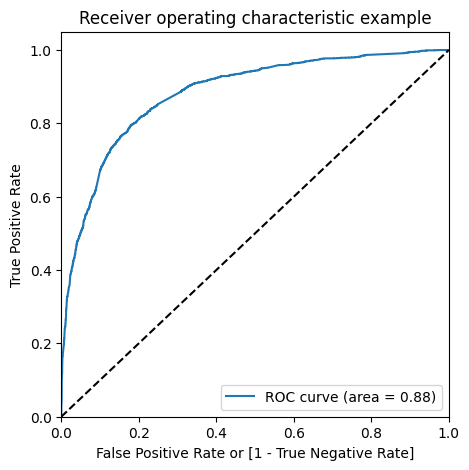

In [163]:
draw_roc(y_train_pred_final.Converted, y_train_pred_final.Converted_prob)

In [164]:
###Optimal cutoff


numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i]= y_train_pred_final.Converted_prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,0.260941,1871,0,1,1,1,0,0,0,0,0,0,0
1,0,0.196936,6795,0,1,1,0,0,0,0,0,0,0,0
2,0,0.303534,3516,0,1,1,1,1,0,0,0,0,0,0
3,0,0.832412,8105,1,1,1,1,1,1,1,1,1,1,0
4,0,0.124689,3934,0,1,1,0,0,0,0,0,0,0,0


In [165]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive 
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.381262  1.000000  0.000000
0.1   0.1  0.591991  0.970803  0.358571
0.2   0.2  0.742579  0.913625  0.637181
0.3   0.3  0.797619  0.826845  0.779610
0.4   0.4  0.815244  0.757908  0.850575
0.5   0.5  0.815708  0.698297  0.888056
0.6   0.6  0.796537  0.592052  0.922539
0.7   0.7  0.780612  0.511354  0.946527
0.8   0.8  0.759431  0.417680  0.970015
0.9   0.9  0.712430  0.263990  0.988756


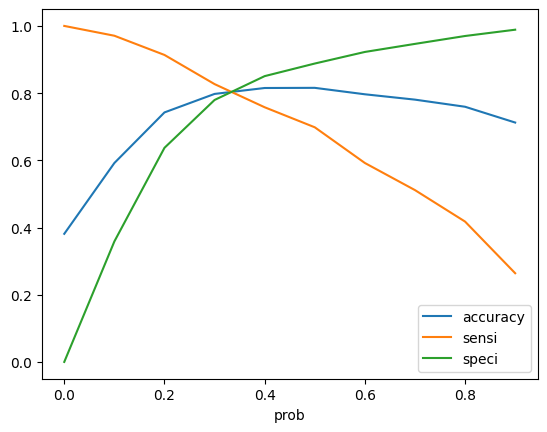

In [166]:
# Let's plot accuracy sensitivity and specificity for various probabilities.
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [167]:
from sklearn.metrics import precision_recall_curve

p, r, thresholds = precision_recall_curve(y_train, y_train_pred)

idx = np.argmin(np.abs(p[:-1] - r[:-1]))

CUTOFF = round(float(thresholds[idx]), 2)

print("Cutoff:", CUTOFF)

Cutoff: 0.4


In [168]:
y_train_pred_final['final_Predicted'] = (
    y_train_pred_final['Converted_prob'] >= CUTOFF
).astype(int)

y_train_pred_final.head()

,Converted,Converted_prob,Prospect ID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_Predicted
0,0,0.260941,1871,0,1,1,1,0,0,0,0,0,0,0,0
1,0,0.196936,6795,0,1,1,0,0,0,0,0,0,0,0,0
2,0,0.303534,3516,0,1,1,1,1,0,0,0,0,0,0,0
3,0,0.832412,8105,1,1,1,1,1,1,1,1,1,1,0,1
4,0,0.124689,3934,0,1,1,0,0,0,0,0,0,0,0,0


In [169]:
y_train_pred_final['Lead_Score'] = y_train_pred_final.Converted_prob.map(lambda x: round(x * 100))
y_train_pred_final[['Converted','Converted_prob','Prospect ID','final_Predicted','Lead_Score']].head()

,Converted,Converted_prob,Prospect ID,final_Predicted,Lead_Score
0,0,0.260941,1871,0,26
1,0,0.196936,6795,0,20
2,0,0.303534,3516,0,30
3,0,0.832412,8105,1,83
4,0,0.124689,3934,0,12


In [170]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_train_pred_final.Converted, y_train_pred_final.final_Predicted)

0.8152442795299938

In [171]:
confusion2 = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_Predicted )
confusion2

array([[3404,  598],
       [ 597, 1869]])

In [172]:
TP = confusion2[1,1] # true positive 
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [173]:
# Let's see the accuracy of our logistic regression model
round((TN+TP) / float(TN+TP+FN+FP), 4)

0.8152

In [174]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

0.7579075425790754

In [175]:
# Let us calculate specificity
TN / float(TN+FP)

0.8505747126436781

In [176]:
# Calculate False Postive Rate - predicting conversion when customer does not have convert
print(FP/ float(TN+FP))

0.14942528735632185


In [177]:
# Positive predictive value 
print (TP / float(TP+FP))

0.7576003242805026


In [178]:
# Negative predictive value
print (TN / float(TN+ FN))

0.8507873031742065


The performance above is based on the training-derived cutoff stored in `CUTOFF`.

In [179]:
confusion = metrics.confusion_matrix(y_train_pred_final.Converted, y_train_pred_final.final_Predicted )
confusion

array([[3404,  598],
       [ 597, 1869]])

In [180]:
# to calculate precision score and recall score

In [181]:
from sklearn.metrics import precision_score, recall_score

In [182]:
precision_score(y_train_pred_final.Converted , y_train_pred_final.final_Predicted)

0.7576003242805026

In [183]:
recall_score(y_train_pred_final.Converted, y_train_pred_final.final_Predicted)

0.7579075425790754

In [184]:
print("Precision score:", round(precision_score(y_train_pred_final.Converted, y_train_pred_final.final_Predicted), 4))
print("Recall score:", round(recall_score(y_train_pred_final.Converted, y_train_pred_final.final_Predicted), 4))

Precision score: 0.7576
Recall score: 0.7579


In [185]:
from sklearn.metrics import precision_recall_curve

In [186]:
p, r, t = precision_recall_curve(
    y_train_pred_final.Converted,
    y_train_pred_final.Converted_prob
)

In [187]:
p, r, t = precision_recall_curve(
    y_train_pred_final.Converted,
    y_train_pred_final.Converted_prob
)

idx = np.argmin(np.abs(p[:-1] - r[:-1]))
CUTOFF = round(float(t[idx]), 2)
print("Cutoff where precision and recall are closest on train:", CUTOFF)

Cutoff where precision and recall are closest on train: 0.4


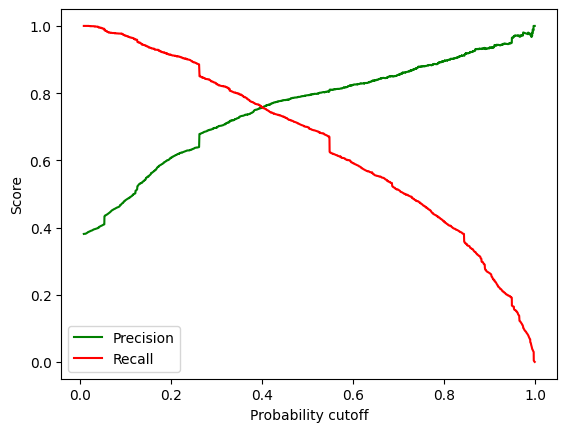

In [188]:
plt.plot(t, p[:-1], "g-")
plt.plot(t, r[:-1], "r-")
plt.xlabel('Probability cutoff')
plt.ylabel('Score')
plt.legend(['Precision', 'Recall'])
plt.show()

The cutoff is selected from the training precision-recall curve as the threshold where precision and recall are closest. The value printed above should be used as the final training cutoff.

## making prediction on the test set

In [189]:
# The scaler was already fitted on the training data and used to transform X_test above.
# We must not fit the scaler again on the test data because that would leak test-set information into preprocessing.
X_test.head()

,Do Not Email,TotalVisits,Total Time Spent on Website,Page Views Per Visit,A free copy of Mastering The Interview,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,Lead Source_OtherLeads,Last Activity_Olark Chat Conversation,Last Activity_OtherLastActivity,Last Activity_Page Visited on Website,Last Activity_SMS Sent,Country_OtherCountries,Occupation_Student,Occupation_Unemployed,Occupation_Working Professional,Last Notable Activity_Modified,Last Notable Activity_OtherLastNotableActivity
4269,0,0.863900,0.964504,2.604962,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
2376,0,-0.645678,-0.885371,-1.062143,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
7766,0,0.297808,-0.777416,1.229797,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1
9199,0,-0.645678,-0.885371,-1.062143,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0
4359,0,-0.645678,-0.885371,-1.062143,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [190]:
# Keep the same predictor columns used by the final Model 5.
X_test = X_test[col]
X_test.head()

,Do Not Email,Total Time Spent on Website,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_OtherLeads,Last Activity_Olark Chat Conversation,Last Activity_SMS Sent,Occupation_Unemployed,Occupation_Working Professional,Last Notable Activity_Modified
4269,0,0.964504,0,0,0,0,0,0,1,1,0,0
2376,0,-0.885371,0,1,0,0,0,0,1,1,0,0
7766,0,-0.777416,0,0,1,0,0,0,0,0,1,0
9199,0,-0.885371,0,0,0,1,0,1,0,1,0,1
4359,0,-0.885371,0,1,0,0,0,0,0,1,0,0


In [191]:
X_test_sm = sm.add_constant(X_test, has_constant='add')

In [192]:
print(X_test_sm.dtypes)
print(X_test_sm.shape)

const                                    float64
Do Not Email                               int64
Total Time Spent on Website              float64
Lead Origin_Landing Page Submission        int64
Lead Origin_Lead Add Form                  int64
Lead Source_Google                         int64
Lead Source_Olark Chat                     int64
Lead Source_OtherLeads                     int64
Last Activity_Olark Chat Conversation      int64
Last Activity_SMS Sent                     int64
Occupation_Unemployed                      int64
Occupation_Working Professional            int64
Last Notable Activity_Modified             int64
dtype: object
(2772, 13)


In [193]:
# statsmodels requires a numeric matrix; convert the selected predictors to float.
X_test_sm = X_test_sm.astype(float)

In [194]:
#TEST SET

y_test_pred = mod_5.predict(X_test_sm)

In [195]:
y_test_pred[:10]

4269    0.742265
2376    0.948662
7766    0.742299
9199    0.052511
4359    0.843477
9186    0.592726
1631    0.484876
8963    0.205841
8007    0.091366
5324    0.372246
dtype: float64

In [196]:
# Converting y_pred to a dataframe which is an array
y_pred_1 = pd.DataFrame(y_test_pred)

In [197]:
y_pred_1.head()

,0
4269,0.742265
2376,0.948662
7766,0.742299
9199,0.052511
4359,0.843477


In [198]:
y_test_df = pd.DataFrame(y_test)
y_test_df.head()


,Converted
4269,1
2376,1
7766,1
9199,0
4359,1


In [199]:
y_test_df['Prospect ID'] = y_test_df.index


y_test_pred.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)


y_pred_final = pd.concat([y_test_df, y_test_pred],axis=1)
y_pred_final.head()

,Converted,Prospect ID,0
0,1,4269,0.742265
1,1,2376,0.948662
2,1,7766,0.742299
3,0,9199,0.052511
4,1,4359,0.843477


In [200]:
y_pred_final= y_pred_final.rename(columns={ 0 : 'Converted_Prob'})


In [201]:
# Apply the cutoff selected from the training data to the test probabilities.
y_pred_final['final_predicted'] = (
    y_pred_final['Converted_Prob'] >= CUTOFF
).astype(int)
y_pred_final.head()

,Converted,Prospect ID,Converted_Prob,final_predicted
0,1,4269,0.742265,1
1,1,2376,0.948662,1
2,1,7766,0.742299,1
3,0,9199,0.052511,0
4,1,4359,0.843477,1


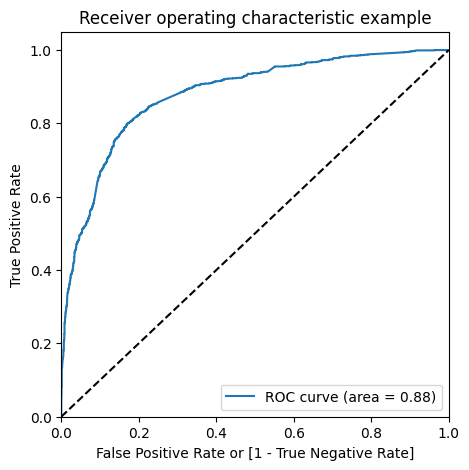

In [202]:
# Drawing ROC curve for Test Set
fpr, tpr, thresholds = metrics.roc_curve(y_pred_final["Converted"], y_pred_final["Converted_Prob"], drop_intermediate = False )

draw_roc(y_pred_final["Converted"], y_pred_final["Converted_Prob"])

In [203]:
confusion3 = metrics.confusion_matrix(y_pred_final['Converted'], y_pred_final['final_predicted'])
print(confusion3)

[[1442  235]
 [ 265  830]]


In [204]:
TP = confusion3[1,1] # true positive 
TN = confusion3[0,0] # true negatives
FP = confusion3[0,1] # false positives
FN = confusion3[1,0] # false negatives

In [205]:
# Let's see the Accuracy of our logistic regression model
round((TN+TP) / float(TN+TP+FN+FP), 4)

0.8196

In [206]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

0.7579908675799086

In [207]:
# Let us calculate specificity
TN / float(TN+FP)

0.8598688133571855

In [208]:
# Calculate False Postive Rate - predicting conversion when customer does not have convert
print(FP/ float(TN+FP))

0.14013118664281454


In [209]:
# Positive predictive value 
print (TP / float(TP+FP))

0.7793427230046949


In [210]:
# Negative predictive value
print (TN / float(TN+ FN))

0.8447568834212068


In [211]:
print("Accuracy of the test set:", round((TN + TP) / float(TN + TP + FN + FP), 4))
print("Sensitivity of the test set:", round(TP / float(TP + FN), 4))
print("Specificity of the test set:", round(TN / float(TN + FP), 4))

Accuracy of the test set: 0.8196
Sensitivity of the test set: 0.758
Specificity of the test set: 0.8599


In [212]:
precision_score(y_pred_final['Converted'],y_pred_final['final_predicted'])

0.7793427230046949

In [213]:
recall_score(y_pred_final['Converted'],y_pred_final['final_predicted'])

0.7579908675799086

In [214]:
p_test, r_test, thresholds_test = precision_recall_curve(
    y_pred_final.Converted,
    y_pred_final.Converted_Prob
)

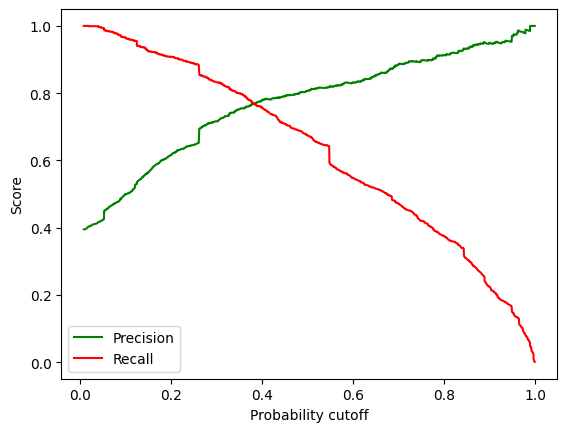

In [215]:
plt.plot(thresholds_test, p_test[:-1], "g-")
plt.plot(thresholds_test, r_test[:-1], "r-")
plt.xlabel('Probability cutoff')
plt.ylabel('Score')
plt.legend(['Precision', 'Recall'])
plt.show()

The test set is evaluated using the same cutoff selected from the training data. The test precision-recall curve is shown for reference only; the test set is not used to select a new cutoff.

In [216]:
y_pred_final['Final_Lead_Score'] = y_pred_final['Converted_Prob'].map( lambda x: round(x*100))
y_pred_final.head(20)

,Converted,Prospect ID,Converted_Prob,final_predicted,Final_Lead_Score
0,1,4269,0.742265,1,74
1,1,2376,0.948662,1,95
2,1,7766,0.742299,1,74
3,0,9199,0.052511,0,5
4,1,4359,0.843477,1,84
5,1,9186,0.592726,1,59
6,1,1631,0.484876,1,48
7,1,8963,0.205841,0,21
8,0,8007,0.091366,0,9
9,1,5324,0.372246,0,37


In [217]:
y_pred_final.sort_values(by='Final_Lead_Score', ascending=False)

,Converted,Prospect ID,Converted_Prob,final_predicted,Final_Lead_Score
2569,1,2675,0.996795,1,100
739,1,5586,0.996795,1,100
745,1,6383,0.998991,1,100
475,1,5825,0.996795,1,100
457,1,4786,0.996795,1,100
...,...,...,...,...,...
116,0,5523,0.012825,0,1
1073,0,8910,0.014341,0,1
1620,0,5897,0.013926,0,1
597,0,3682,0.012651,0,1


In [218]:
auc_test = metrics.roc_auc_score(y_pred_final['Converted'], y_pred_final['Converted_Prob'])
base_rate = y_pred_final['Converted'].mean()
flagged = y_pred_final[y_pred_final.final_predicted == 1]
hot_rate = flagged['Converted'].mean()
print("Test AUC:", round(auc_test, 3))
print("Base conversion rate:", round(base_rate, 3))
print("Flagged lead conversion rate:", round(hot_rate, 3))
print("Lift:", round(hot_rate / base_rate, 2))

Test AUC: 0.879
Base conversion rate: 0.395
Flagged lead conversion rate: 0.779
Lift: 1.97


In [219]:
# Additional diagnostic model excluding Last Activity and Last Notable Activity variables.
# This is kept as a sensitivity check and is not used as the final model, because Model 5 above is the final model used
# for the main test-set evaluation.
cols_clean = [
    c for c in col
    if not c.startswith('Last Activity')
    and not c.startswith('Last Notable Activity')
]

X_train_clean = X_train[cols_clean].astype(float)
X_train_clean_sm = sm.add_constant(X_train_clean, has_constant='add')

mod_clean = sm.GLM(
    y_train,
    X_train_clean_sm,
    family=sm.families.Binomial()
).fit()

p_tr = mod_clean.predict(X_train_clean_sm)
pp, rr, tt = precision_recall_curve(y_train, p_tr)
idx = np.argmin(np.abs(pp[:-1] - rr[:-1]))
cut_clean = round(float(tt[idx]), 2)

X_test_clean = X_test[cols_clean].astype(float)
X_test_clean_sm = sm.add_constant(X_test_clean, has_constant='add')
p_te = mod_clean.predict(X_test_clean_sm)

pred = (p_te >= cut_clean).astype(int)

print("Diagnostic cutoff:", cut_clean)
print("Diagnostic Accuracy:", round(metrics.accuracy_score(y_test, pred), 3))
print("Diagnostic Recall:", round(metrics.recall_score(y_test, pred), 3))
print("Diagnostic Precision:", round(metrics.precision_score(y_test, pred), 3))
print("Diagnostic AUC:", round(metrics.roc_auc_score(y_test, p_te), 3))

Diagnostic cutoff: 0.34
Diagnostic Accuracy: 0.794
Diagnostic Recall: 0.734
Diagnostic Precision: 0.741
Diagnostic AUC: 0.831


Final_Lead_Score represents the model's estimated probability of conversion expressed on a 0–100 scale. A higher score indicates that the model estimates a higher likelihood that the lead will convert.